# Analysis-A: Relationship Between Input Fields and Response Outcomes

This notebook analyzes the relationship between each input field in the complaints dataset and the following response/resolution fields:

1. **Company response to consumer**
2. **Timely response?**
3. **Company public response**

We use cross-tabulation, chi-square tests, and effect size (Cramér's V) to identify and visualize the strongest associations.

In [42]:
# Section 1: Import libraries and set up
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
%matplotlib inline

In [43]:
# Section 2: Load data
data_path = Path('../data/complaints-2026-05-17_11_33.csv')
print(f'Loading data from {data_path} ...')
df = pd.read_csv(data_path)
print(f'Data loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
df.head()

Loading data from ../data/complaints-2026-05-17_11_33.csv ...
Data loaded: 176,942 rows, 18 columns


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,04/01/20,Checking or savings account,Checking account,Managing an account,Deposits and withdrawals,On XX/XX/2020 I deposited my check of {$320.00...,NaN,Synovus Bank,FL,323XX,NaN,Consent provided,Web,04/01/20,Closed with explanation,Yes,NaN,3589185
1,04/28/24,Checking or savings account,Checking account,Problem with a lender or other company chargin...,Transaction was not authorized,"On or about XX/XX/XXXX, I noticed there were a...",NaN,CAPITAL ONE FINANCIAL CORPORATION,MA,019XX,Servicemember,Consent provided,Web,04/28/24,Closed with explanation,Yes,NaN,8873634
2,07/10/20,Checking or savings account,Checking account,Managing an account,Deposits and withdrawals,On XXXX XXXX around XXXX PST. My husband was s...,Company believes it acted appropriately as aut...,NAVY FEDERAL CREDIT UNION,NV,89052,Servicemember,Consent provided,Web,07/10/20,Closed with explanation,Yes,NaN,3739701
3,05/07/19,Checking or savings account,Checking account,Problem with a lender or other company chargin...,Transaction was not authorized,I closed my XXXX XXXX account in XXXX of XXXX....,NaN,AMERICAN EXPRESS COMPANY,OK,73120,NaN,Consent provided,Web,05/07/19,Closed with explanation,Yes,NaN,3235193
4,12/11/23,Checking or savings account,Checking account,Managing an account,Deposits and withdrawals,I opened an Account with fifth third bank on X...,NaN,FIFTH THIRD FINANCIAL CORPORATION,FL,32817,NaN,Consent provided,Web,12/11/23,Closed with explanation,Yes,NaN,7985106


In [44]:
# Section 3: Data overview
print('Column names:')
print(df.columns.tolist())
print('\nData types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())
df.describe(include='all').T

Column names:
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']

Data types:
Date received                    object
Product                          object
Sub-product                      object
Issue                            object
Sub-issue                        object
Consumer complaint narrative     object
Company public response          object
Company                          object
State                            object
ZIP code                         object
Tags                             object
Consumer consent provided?       object
Submitted via                    object
Date sent to company             object
Company response to consumer     object
Timely response?                 object
Consume

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date received,176942,3274,01/17/25,3321,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,176942,1,Checking or savings account,176942,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sub-product,176907,4,Checking account,145900,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Issue,176942,13,Managing an account,96156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sub-issue,176822,50,Deposits and withdrawals,33979,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Consumer complaint narrative,176942,172697,I am writing to file a complaint against Navy ...,2411,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Company public response,88850,10,Company has responded to the consumer and the ...,73943,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Company,176942,687,WELLS FARGO & COMPANY,21225,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,175451,62,CA,25477,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ZIP code,176942,6890,XXXXX,10934,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
def cramers_v(chi2, n, r, k):
    """Calculate Cramér's V effect size"""
    return np.sqrt(chi2 / (n * min(k-1, r-1))) if min(k-1, r-1) > 0 else 0

def analyze_relationship(df, input_field, target_field):
    """Compute cross-tabulation and chi-square test for a pair of fields"""
    ct = pd.crosstab(df[input_field], df[target_field])
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return None
    chi2, p, dof, expected = chi2_contingency(ct)
    n = ct.sum().sum()
    r, k = ct.shape
    v = cramers_v(chi2, n, r, k)
    
    return {
        'input_field': input_field,
        'chi2': chi2,
        'p_value': p,
        'cramers_v': v,
        'n': n,
        'categories': r,
        'target_categories': k,
        'contingency_table': ct
    }

def analyze_target_field(df, input_fields, target_field):
    """Analyze all input fields against a target field"""
    results = []
    for field in input_fields:
        if field == target_field or df[field].isnull().sum() / len(df) > 0.5:
            continue
        result = analyze_relationship(df, field, target_field)
        if result:
            results.append(result)
    return pd.DataFrame([{k: v for k, v in r.items() if k != 'contingency_table'} for r in results])

# Define input and target fields
input_fields = ['Product', 'Sub-product', 'Issue', 'Sub-issue', 'Company', 'State', 'Tags',
                'Consumer consent provided?', 'Submitted via', 'Consumer disputed?']
target_fields = ['Company response to consumer', 'Timely response?', 'Company public response']

print(f"Input fields: {len(input_fields)}")
print(f"Target fields: {len(target_fields)}")


Input fields: 10
Target fields: 3


### Three Key Modeling Targets

In [88]:
distinct_values = df['Company public response'].unique()
print(distinct_values)

[nan
 'Company believes it acted appropriately as authorized by contract or law'
 'Company has responded to the consumer and the CFPB and chooses not to provide a public response'
 'Company believes complaint is the result of an isolated error'
 'Company believes complaint represents an opportunity for improvement to better serve consumers'
 "Company can't verify or dispute the facts in the complaint"
 'Company believes complaint caused principally by actions of third party outside the control or direction of the company'
 'Company believes the complaint is the result of a misunderstanding'
 "Company believes the complaint provided an opportunity to answer consumer's questions"
 'Company disputes the facts presented in the complaint'
 'Company believes complaint relates to a discontinued policy or procedure']


Data Distribution:
 Company public response
Company has responded to the consumer and the CFPB and chooses not to provide a public response                            73943
Company believes it acted appropriately as authorized by contract or law                                                   13955
Company believes the complaint provided an opportunity to answer consumer's questions                                        288
Company believes complaint represents an opportunity for improvement to better serve consumers                               258
Company believes complaint is the result of an isolated error                                                                191
Company believes the complaint is the result of a misunderstanding                                                            86
Company believes complaint caused principally by actions of third party outside the control or direction of the company       76
Company disputes the facts presented in the complaint

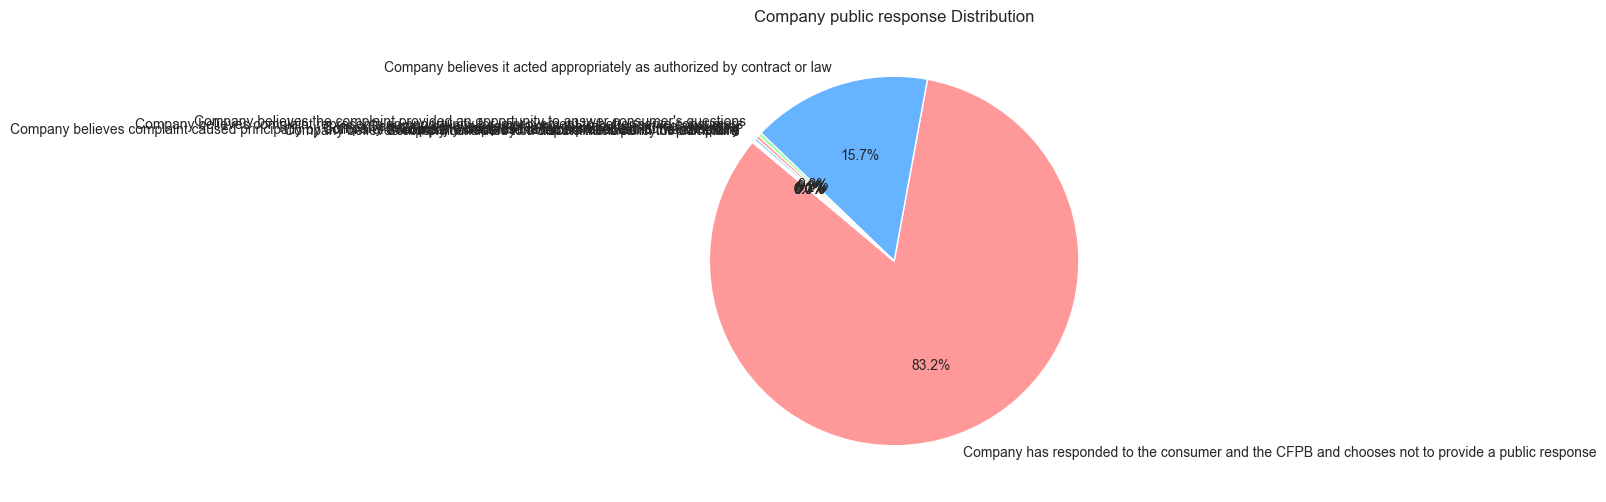

In [89]:
# 2. Check the distribution (returns frequencies of each unique category)
distribution = df["Company public response"].value_counts()
print("Data Distribution:\n", distribution)

# 3. Draw the pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    distribution,
    labels=distribution.index,
    autopct="%1.1f%%",  # Displays percentages automatically
    startangle=140,  # Rotates the start point for a cleaner look
    colors=["#ff9999", "#66b3ff", "#99ff99"],  # Optional custom colors
)

plt.title("Company public response Distribution")
plt.show()

In [90]:
distinct_values = df['Timely response?'].unique()
print(distinct_values)

['Yes' 'No']


Data Distribution:
 Timely response?
Yes    175206
No       1736
Name: count, dtype: int64


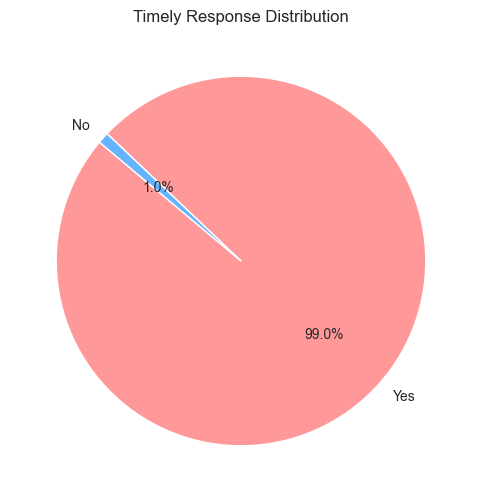

In [91]:
# 2. Check the distribution (returns frequencies of each unique category)
distribution = df['Timely response?'].value_counts()
print("Data Distribution:\n", distribution)

# 3. Draw the pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    distribution,
    labels=distribution.index,
    autopct="%1.1f%%",  # Displays percentages automatically
    startangle=140,  # Rotates the start point for a cleaner look
    colors=["#ff9999", "#66b3ff", "#99ff99"],  # Optional custom colors
)

plt.title("Timely Response Distribution")
plt.show()

In [92]:
distinct_values = df['Company response to consumer'].unique()
print(distinct_values)

['Closed with explanation' 'Closed with monetary relief'
 'Closed with non-monetary relief' 'Untimely response' 'In progress']


Data Distribution:
 Company response to consumer
Closed with explanation            140703
Closed with monetary relief         26445
Closed with non-monetary relief      9661
Untimely response                     129
In progress                             4
Name: count, dtype: int64


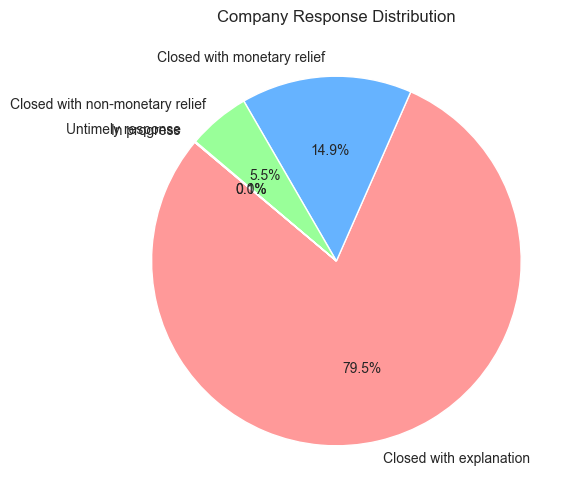

In [93]:
# 2. Check the distribution (returns frequencies of each unique category)
distribution = df['Company response to consumer'].value_counts()
print("Data Distribution:\n", distribution)

# 3. Draw the pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    distribution,
    labels=distribution.index,
    autopct="%1.1f%%",  # Displays percentages automatically
    startangle=140,  # Rotates the start point for a cleaner look
    colors=["#ff9999", "#66b3ff", "#99ff99"],  # Optional custom colors
)

plt.title("Company Response Distribution")
plt.show()

### Company response to consumer

In [46]:
distinct_values = df['Company response to consumer'].unique()
print(distinct_values)

['Closed with explanation' 'Closed with monetary relief'
 'Closed with non-monetary relief' 'Untimely response' 'In progress']


In [47]:
distinct_values = df['Company'].unique()
print(distinct_values)

['Synovus Bank' 'CAPITAL ONE FINANCIAL CORPORATION'
 'NAVY FEDERAL CREDIT UNION' 'AMERICAN EXPRESS COMPANY'
 'FIFTH THIRD FINANCIAL CORPORATION' 'PNC Bank N.A.'
 'JPMORGAN CHASE & CO.' 'WELLS FARGO & COMPANY'
 'BANK OF AMERICA, NATIONAL ASSOCIATION' 'U.S. BANCORP'
 'BBVA FINANCIAL CORPORATION' 'INVESTORS BANK'
 'TD BANK US HOLDING COMPANY' 'HSBC NORTH AMERICA HOLDINGS INC.'
 'MoneyLion Inc.' 'BMO BANK NATIONAL ASSOCIATION'
 'TRUIST FINANCIAL CORPORATION' 'UNITED SERVICES AUTOMOBILE ASSOCIATION'
 'WEBSTER BANK, NATIONAL ASSOCIATION' 'GOLDMAN SACHS BANK USA'
 'CITIBANK, N.A.' 'DOLLAR MUTUAL BANCORP' 'ROBINHOOD MARKETS INC.'
 'CITIZENS FINANCIAL GROUP, INC.' 'Paypal Holdings, Inc'
 'Branch Messenger, Inc.' 'Chime Financial Inc'
 'SANTANDER HOLDINGS USA, INC.' 'AXOS FINANCIAL, INC.'
 'SOFI TECHNOLOGIES, INC.' 'UMB FINANCIAL CORPORATION'
 'Social Finance, Inc.' 'ALLY FINANCIAL INC.'
 'REGIONS FINANCIAL CORPORATION' 'Block, Inc.' 'DISCOVER BANK'
 'Fidelity National Information Services, Inc.

Data Distribution:
 Company
WELLS FARGO & COMPANY                    21225
JPMORGAN CHASE & CO.                     20857
BANK OF AMERICA, NATIONAL ASSOCIATION    18967
NAVY FEDERAL CREDIT UNION                11656
CAPITAL ONE FINANCIAL CORPORATION        10542
                                         ...  
Xapo, Inc.                                   1
Advantage One Credit, LLC                    1
Empowerment Ventures, LLC                    1
MILLENNIUM FINANCIAL GROUP, L.L.C.           1
Lil' Wave Financial, Inc.                    1
Name: count, Length: 687, dtype: int64


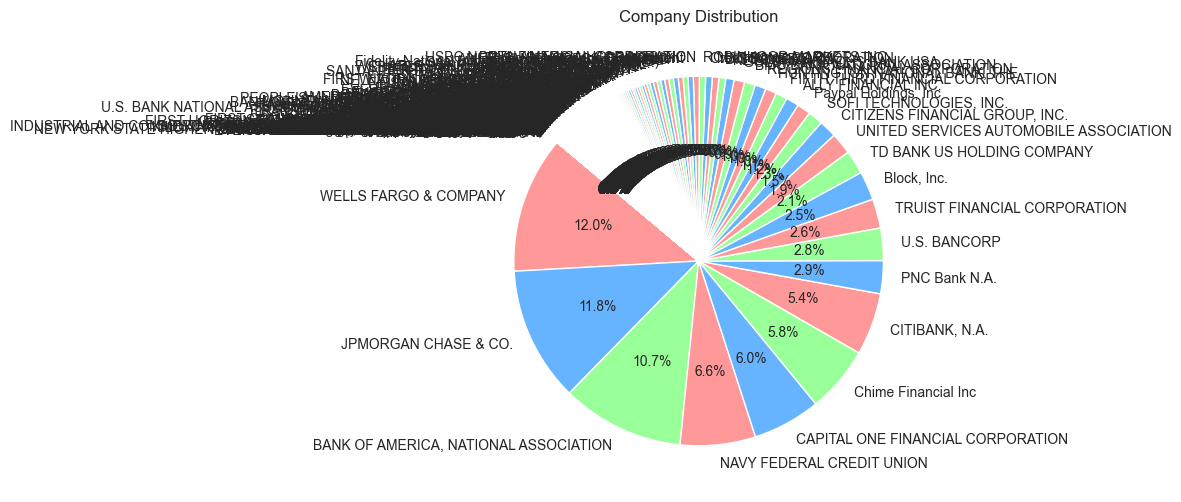

In [48]:
# 2. Check the distribution (returns frequencies of each unique category)
distribution = df["Company"].value_counts()
print("Data Distribution:\n", distribution)

# 3. Draw the pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    distribution,
    labels=distribution.index,
    autopct="%1.1f%%",  # Displays percentages automatically
    startangle=140,  # Rotates the start point for a cleaner look
    colors=["#ff9999", "#66b3ff", "#99ff99"],  # Optional custom colors
)

plt.title("Company Distribution")
plt.show()

In [49]:
distribution.head(20)

Company
WELLS FARGO & COMPANY                     21225
JPMORGAN CHASE & CO.                      20857
BANK OF AMERICA, NATIONAL ASSOCIATION     18967
NAVY FEDERAL CREDIT UNION                 11656
CAPITAL ONE FINANCIAL CORPORATION         10542
Chime Financial Inc                       10230
CITIBANK, N.A.                             9622
PNC Bank N.A.                              5100
U.S. BANCORP                               5017
TRUIST FINANCIAL CORPORATION               4520
Block, Inc.                                4448
TD BANK US HOLDING COMPANY                 3677
UNITED SERVICES AUTOMOBILE ASSOCIATION     3364
CITIZENS FINANCIAL GROUP, INC.             2727
SOFI TECHNOLOGIES, INC.                    2311
Paypal Holdings, Inc                       2115
ALLY FINANCIAL INC.                        2014
FIFTH THIRD FINANCIAL CORPORATION          1776
HUNTINGTON NATIONAL BANK, THE              1749
REGIONS FINANCIAL CORPORATION              1706
Name: count, dtype: int64

In [50]:
# Conditions
conditions = [
    (df["Company"] == "WELLS FARGO & COMPANY"),
    (df["Company"] == "JPMORGAN CHASE & CO."),
    (df["Company"] == "BANK OF AMERICA, NATIONAL ASSOCIATION"),
    (df["Company"] == "NAVY FEDERAL CREDIT UNION"),
    (df["Company"] == "CAPITAL ONE FINANCIAL CORPORATION"),
    (df["Company"] == "Chime Financial Inc"),
    (df["Company"] == "CITIBANK, N.A."),
    (df["Company"] == "PNC Bank N.A."),
    (df["Company"] == "U.S. BANCORP"),
    (df["Company"] == "TRUIST FINANCIAL CORPORATION"),
    (df["Company"] == "Block, Inc."),
    (df["Company"] == "TD BANK US HOLDING COMPANY"),
    (df["Company"] == "UNITED SERVICES AUTOMOBILE ASSOCIATION"),
    (df["Company"] == "CITIZENS FINANCIAL GROUP, INC."),
]

# Categories to assign
categories = ["WELLS FARGO & COMPANY", "JPMORGAN CHASE & CO.", "BANK OF AMERICA, NATIONAL ASSOCIATION", "NAVY FEDERAL CREDIT UNION", "CAPITAL ONE FINANCIAL CORPORATION", "Chime Financial Inc", "CITIBANK, N.A.", "PNC Bank N.A.", "U.S. BANCORP", "TRUIST FINANCIAL CORPORATION", "Block, Inc.", "TD BANK US HOLDING COMPANY", "UNITED SERVICES AUTOMOBILE ASSOCIATION", "CITIZENS FINANCIAL GROUP, INC."]

# Define new column variable based on categories
df["Company_Group"] = np.select(conditions, categories, default="Others")
print(df)

       Date received                      Product       Sub-product  \
0           04/01/20  Checking or savings account  Checking account   
1           04/28/24  Checking or savings account  Checking account   
2           07/10/20  Checking or savings account  Checking account   
3           05/07/19  Checking or savings account  Checking account   
4           12/11/23  Checking or savings account  Checking account   
...              ...                          ...               ...   
176937      09/12/25  Checking or savings account  Checking account   
176938      09/07/23  Checking or savings account  Checking account   
176939      05/23/25  Checking or savings account  Checking account   
176940      03/06/25  Checking or savings account  Checking account   
176941      03/06/24  Checking or savings account  Checking account   

                                                    Issue  \
0                                     Managing an account   
1       Problem with a le

Data Distribution:
 Company_Group
Others                                    44990
WELLS FARGO & COMPANY                     21225
JPMORGAN CHASE & CO.                      20857
BANK OF AMERICA, NATIONAL ASSOCIATION     18967
NAVY FEDERAL CREDIT UNION                 11656
CAPITAL ONE FINANCIAL CORPORATION         10542
Chime Financial Inc                       10230
CITIBANK, N.A.                             9622
PNC Bank N.A.                              5100
U.S. BANCORP                               5017
TRUIST FINANCIAL CORPORATION               4520
Block, Inc.                                4448
TD BANK US HOLDING COMPANY                 3677
UNITED SERVICES AUTOMOBILE ASSOCIATION     3364
CITIZENS FINANCIAL GROUP, INC.             2727
Name: count, dtype: int64


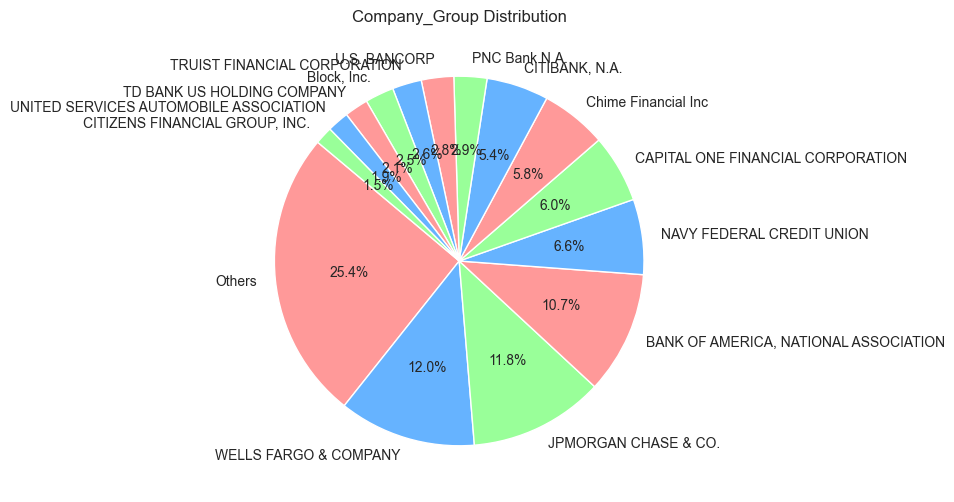

In [51]:
# 2. Check the distribution (returns frequencies of each unique category)
distribution = df["Company_Group"].value_counts()
print("Data Distribution:\n", distribution)

# 3. Draw the pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    distribution,
    labels=distribution.index,
    autopct="%1.1f%%",  # Displays percentages automatically
    startangle=140,  # Rotates the start point for a cleaner look
    colors=["#ff9999", "#66b3ff", "#99ff99"],  # Optional custom colors
)

plt.title("Company_Group Distribution")
plt.show()

### Ratio by Company Over Time

The following plots show the daily ratio of 'Closed with monetary relief' for each of the top 6 companies.

In [ ]:
df['Date received'] = pd.to_datetime(df['Date received'])

In [54]:
df['Date received'] = df['Date received'].dt.to_period('M')

In [ ]:
# 1. Overall ratio by date
# Ensure date is datetime

daily = df.groupby('Date received').agg(
    total_count = ('Company response to consumer', 'count'),
    closed_monetary = ('Company response to consumer', lambda x: (x == 'Closed with monetary relief').sum())
)
daily['ratio'] = daily['closed_monetary'] / daily['total_count'] * 100

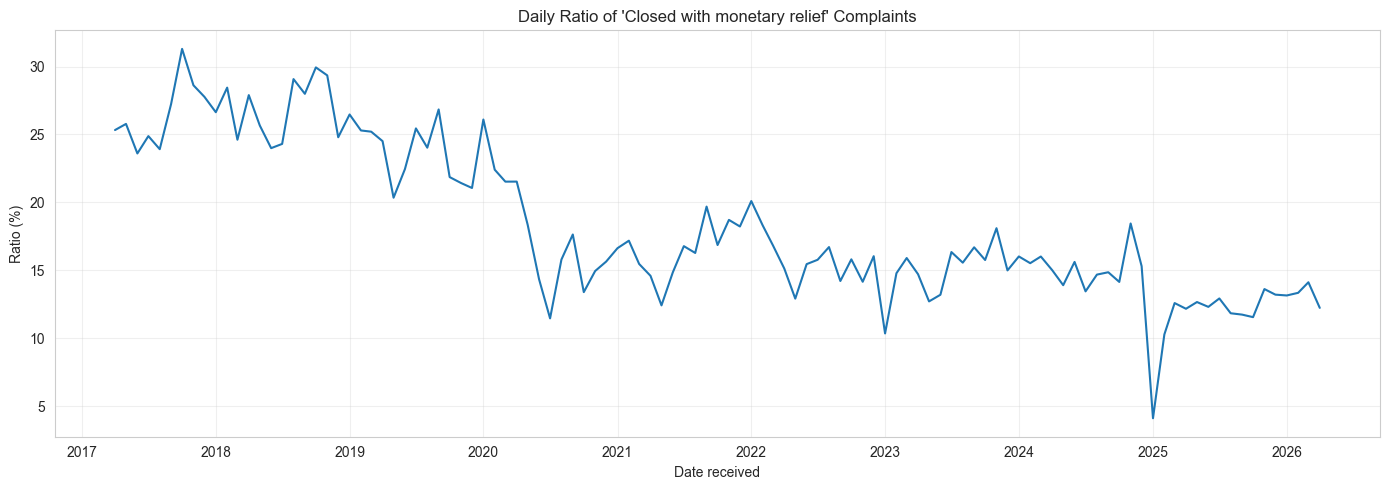

In [65]:
plt.figure(figsize=(14, 5))
plt.plot(daily.index.to_timestamp(), daily['ratio'], label="% Closed with monetary relief", color='tab:blue')
plt.ylabel('Ratio (%)')
plt.xlabel('Date received')
plt.title("Daily Ratio of 'Closed with monetary relief' Complaints")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

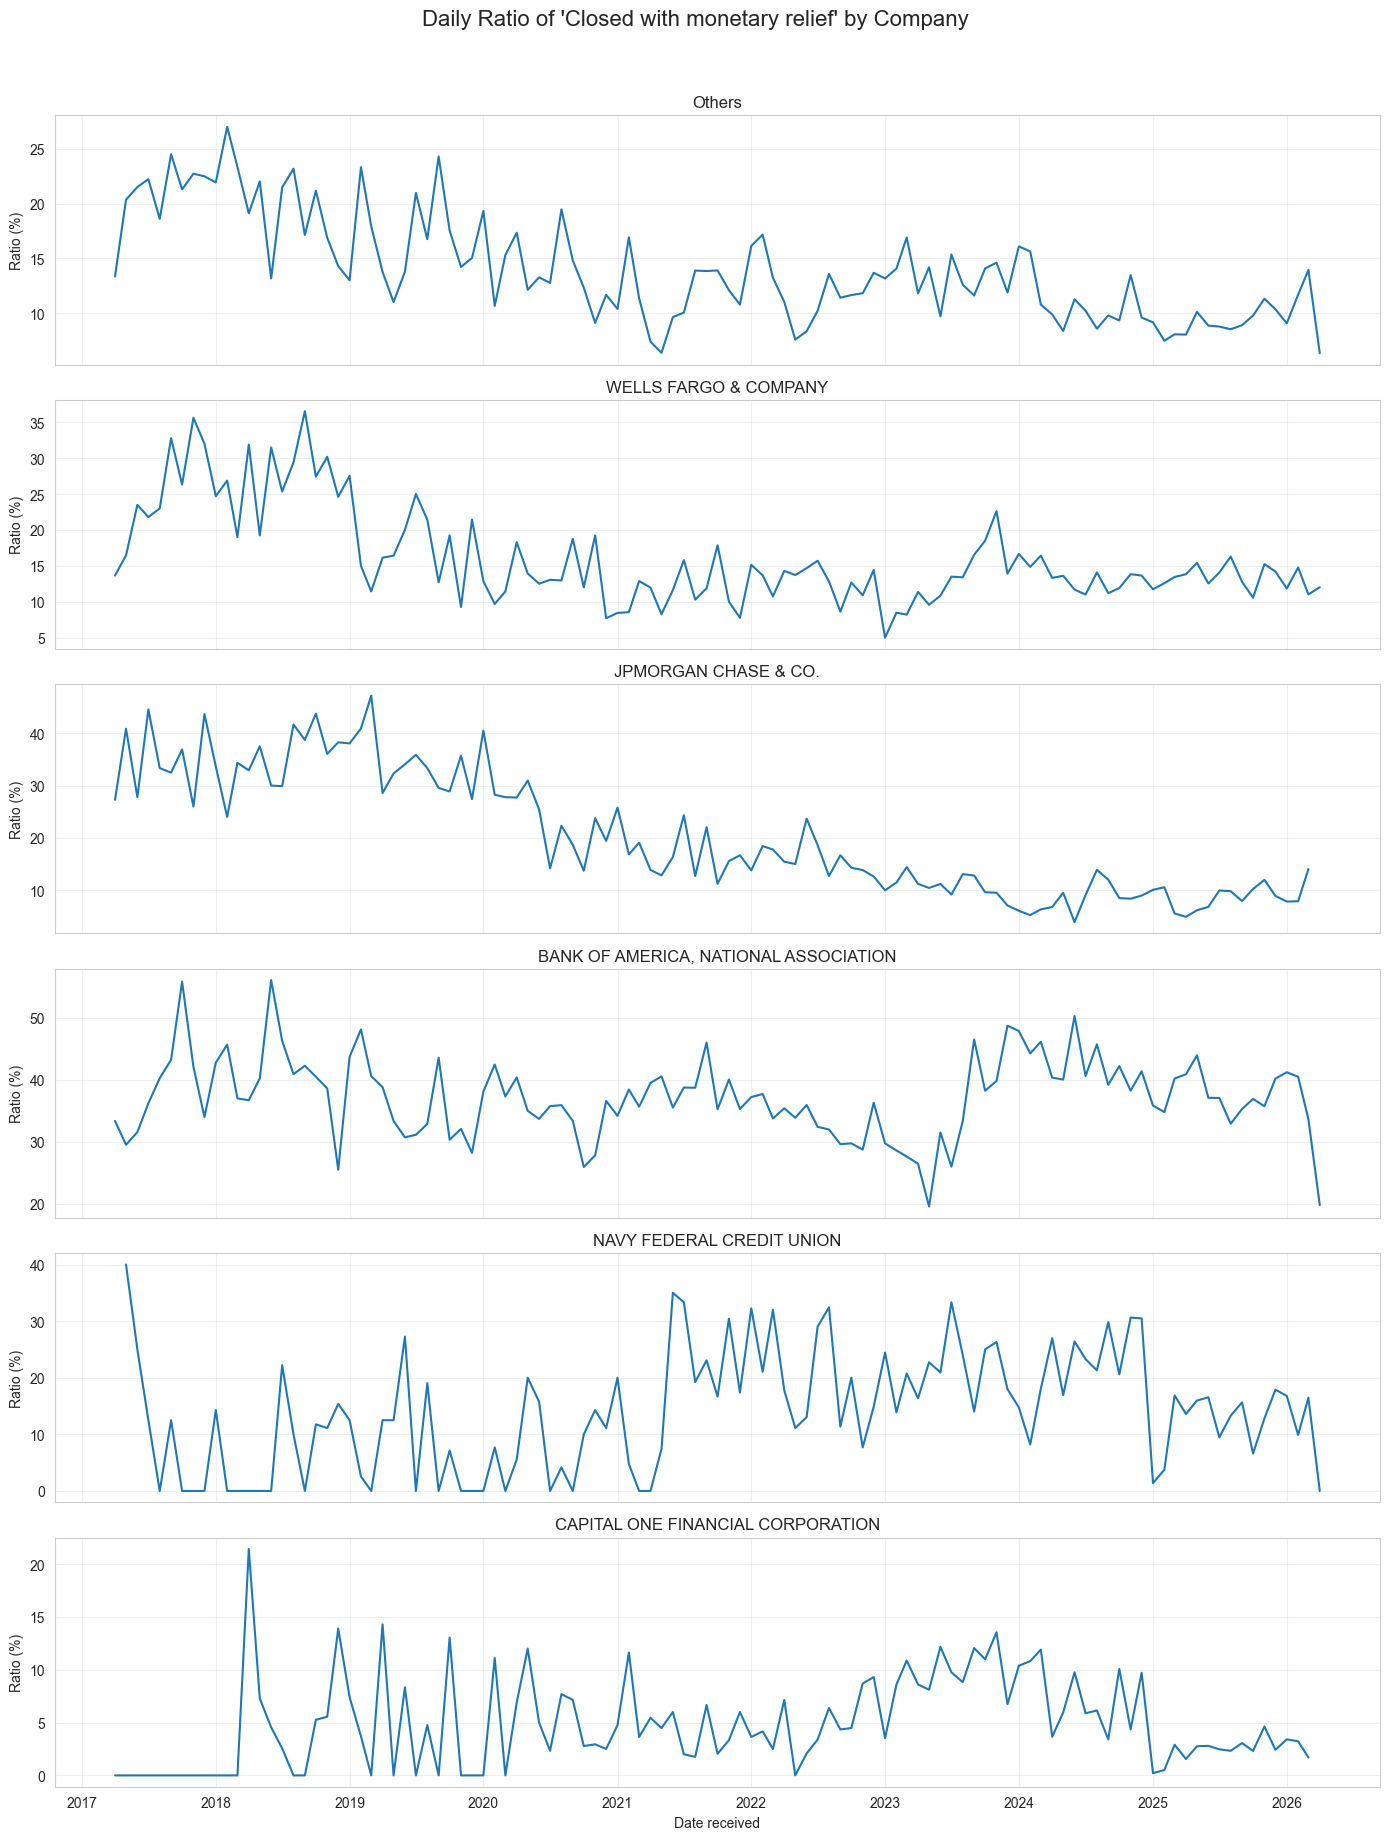

In [66]:
"# 2. Ratio by company over time",
companies = df['Company_Group'].value_counts().index[:6]  # Top 6 companies for clarity",
fig, axes = plt.subplots(len(companies), 1, figsize=(14, 3 * len(companies)), sharex=True)

for i, company in enumerate(companies):
    sub = df[df['Company_Group'] == company]
    daily = sub.groupby('Date received').agg(
    total_count = ('Company response to consumer', 'count'),
    closed_monetary = ('Company response to consumer', 
                       lambda x: (x == 'Closed with monetary relief').sum()))
    daily['ratio'] = daily['closed_monetary'] / daily['total_count'] * 100
    axes[i].plot(daily.index.to_timestamp(), daily['ratio'], label=company, color='tab:blue')
    axes[i].set_ylabel('Ratio (%)')
    axes[i].set_title(f"{company}")
    axes[i].grid(True, alpha=0.3)
    axes[-1].set_xlabel('Date received')
    
plt.suptitle("Daily Ratio of 'Closed with monetary relief' by Company", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

### Ratio by Issues

In [67]:
distinct_values = df['Issue'].unique()
print(distinct_values)

['Managing an account'
 'Problem with a lender or other company charging your account'
 'Closing an account' 'Opening an account'
 'Problem caused by your funds being low'
 "Problem with a company's investigation into an existing problem"
 'Unable to get your credit report or credit score'
 'Credit monitoring or identity theft protection services'
 'Improper use of your report' 'Incorrect information on your report'
 "Problem with a credit reporting company's investigation into an existing problem"
 'Problem with fraud alerts or security freezes'
 'Getting a line of credit']


Data Distribution:
 Issue
Managing an account                                                                 96156
Closing an account                                                                  24533
Problem with a lender or other company charging your account                        21609
Problem caused by your funds being low                                              18045
Opening an account                                                                  15667
Incorrect information on your report                                                  338
Problem with a company's investigation into an existing problem                       192
Improper use of your report                                                           126
Problem with fraud alerts or security freezes                                         119
Credit monitoring or identity theft protection services                                80
Problem with a credit reporting company's investigation into an existing p

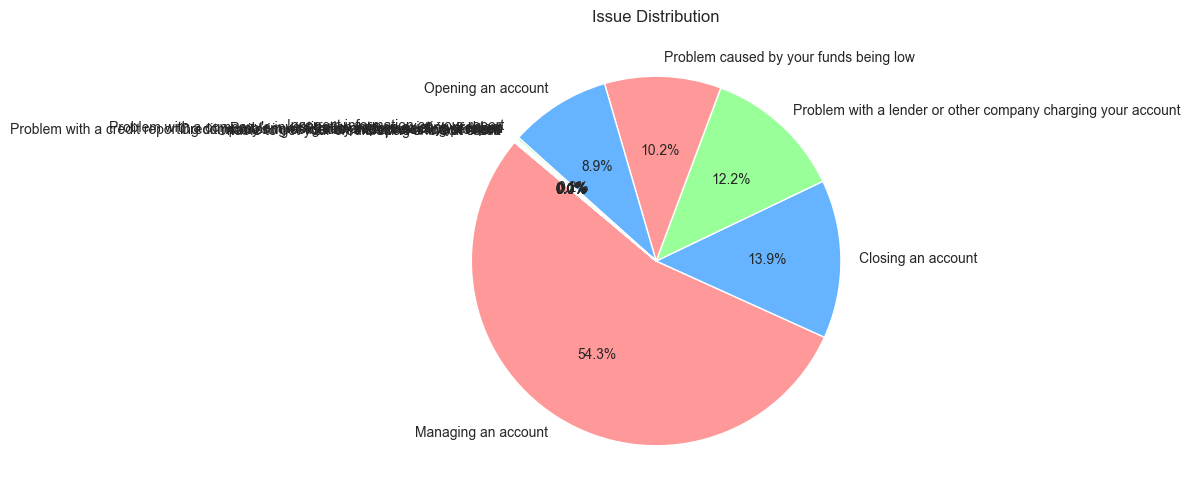

In [68]:
# 2. Check the distribution (returns frequencies of each unique category)
distribution = df["Issue"].value_counts()
print("Data Distribution:\n", distribution)

# 3. Draw the pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    distribution,
    labels=distribution.index,
    autopct="%1.1f%%",  # Displays percentages automatically
    startangle=140,  # Rotates the start point for a cleaner look
    colors=["#ff9999", "#66b3ff", "#99ff99"],  # Optional custom colors
)

plt.title("Issue Distribution")
plt.show()

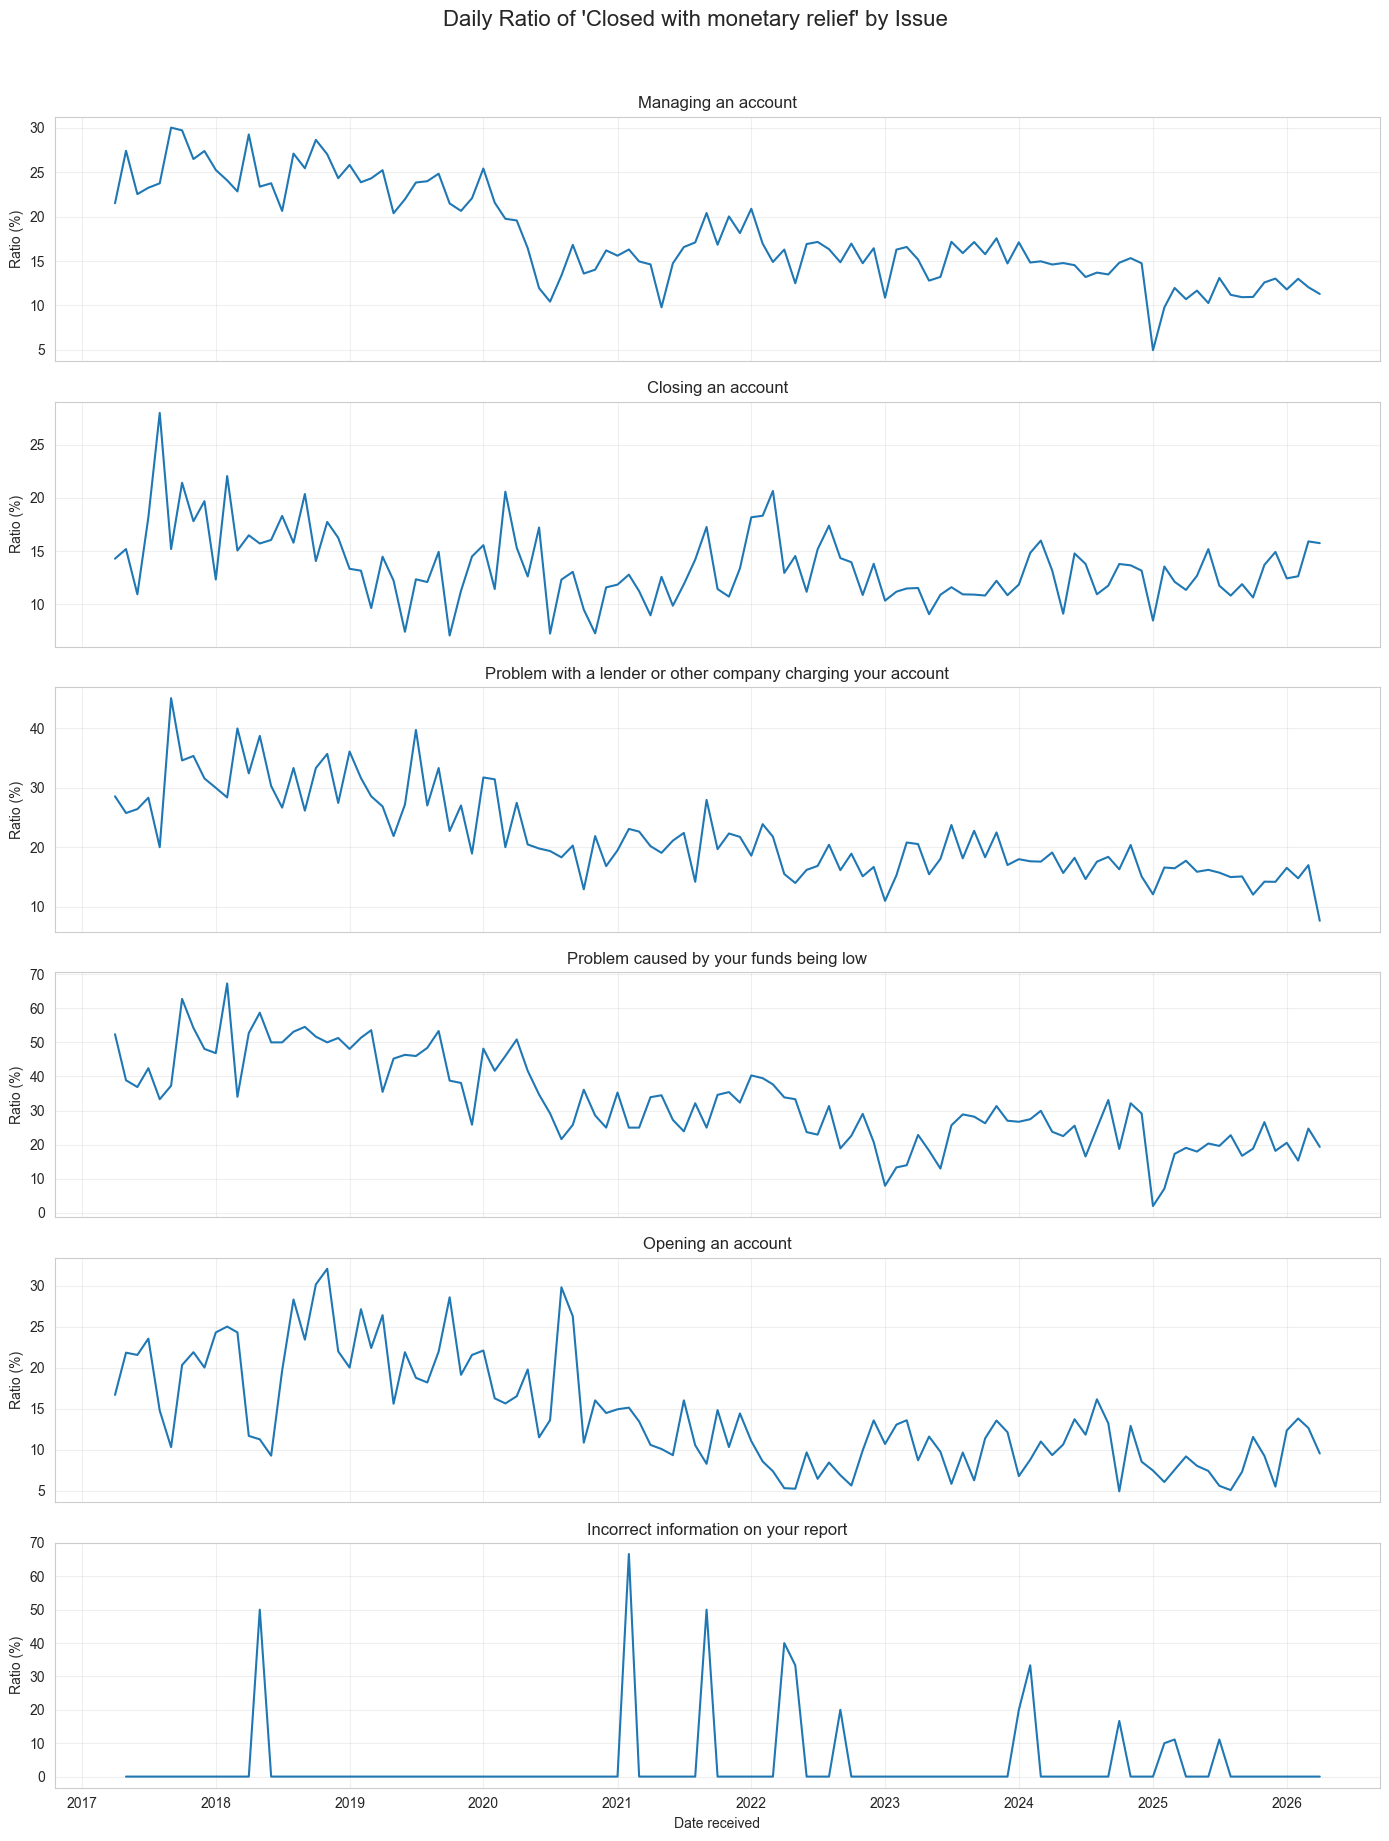

In [70]:
"# 2. Ratio by Issue over time",
issues = df['Issue'].value_counts().index[:6]  # Top 6 issues for clarity",
fig, axes = plt.subplots(len(issues), 1, figsize=(14, 3 * len(issues)), sharex=True)

for i, issue in enumerate(issues):
    sub = df[df['Issue'] == issue]
    daily = sub.groupby('Date received').agg(
    total_count = ('Company response to consumer', 'count'),
    closed_monetary = ('Company response to consumer', 
                       lambda x: (x == 'Closed with monetary relief').sum()))
    daily['ratio'] = daily['closed_monetary'] / daily['total_count'] * 100
    axes[i].plot(daily.index.to_timestamp(), daily['ratio'], label=issue, color='tab:blue')
    axes[i].set_ylabel('Ratio (%)')
    axes[i].set_title(f"{issue}")
    axes[i].grid(True, alpha=0.3)
    axes[-1].set_xlabel('Date received')
    
plt.suptitle("Daily Ratio of 'Closed with monetary relief' by Issue", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

### Ratio by Sub-Issues & Issue vs Sub-Issues relationshio

In [77]:
distinct_values = df['Issue'].unique()
print(distinct_values)

['Managing an account'
 'Problem with a lender or other company charging your account'
 'Closing an account' 'Opening an account'
 'Problem caused by your funds being low'
 "Problem with a company's investigation into an existing problem"
 'Unable to get your credit report or credit score'
 'Credit monitoring or identity theft protection services'
 'Improper use of your report' 'Incorrect information on your report'
 "Problem with a credit reporting company's investigation into an existing problem"
 'Problem with fraud alerts or security freezes'
 'Getting a line of credit']


In [78]:
distinct_values = df['Sub-issue'].unique()
print(distinct_values)

['Deposits and withdrawals' 'Transaction was not authorized'
 'Problem making or receiving payments' 'Problem accessing account'
 'Funds not handled or disbursed as instructed'
 'Problem using a debit or ATM card'
 'Funds not received from closed account' 'Company closed your account'
 'Banking errors' "Didn't receive terms that were advertised"
 'Bounced checks or returned payments' 'Cashing a check'
 "Can't stop withdrawals from your account" 'Unable to open an account'
 "Can't close your account" 'Fee problem' 'Overdrafts and overdraft fees'
 'Fees charged for closing account' 'Account opened as a result of fraud'
 'Money was taken from your account on the wrong day or for the wrong amount'
 'Account opened without my consent or knowledge'
 'Deposits or withdrawals' 'Non-sufficient funds and associated fees'
 'Problem with personal statement of dispute' 'Late or other fees'
 'Other problem getting your report or credit score'
 'Confusing or missing disclosures'
 "Didn't receive serv

Data Distribution:
 Sub-issue
Deposits and withdrawals                                                                 33979
Problem using a debit or ATM card                                                        18665
Transaction was not authorized                                                           17344
Overdrafts and overdraft fees                                                            13075
Funds not handled or disbursed as instructed                                             11810
Company closed your account                                                              10486
Banking errors                                                                            9890
Problem accessing account                                                                 8478
Funds not received from closed account                                                    8471
Problem making or receiving payments                                                      6148
Unable to open an ac

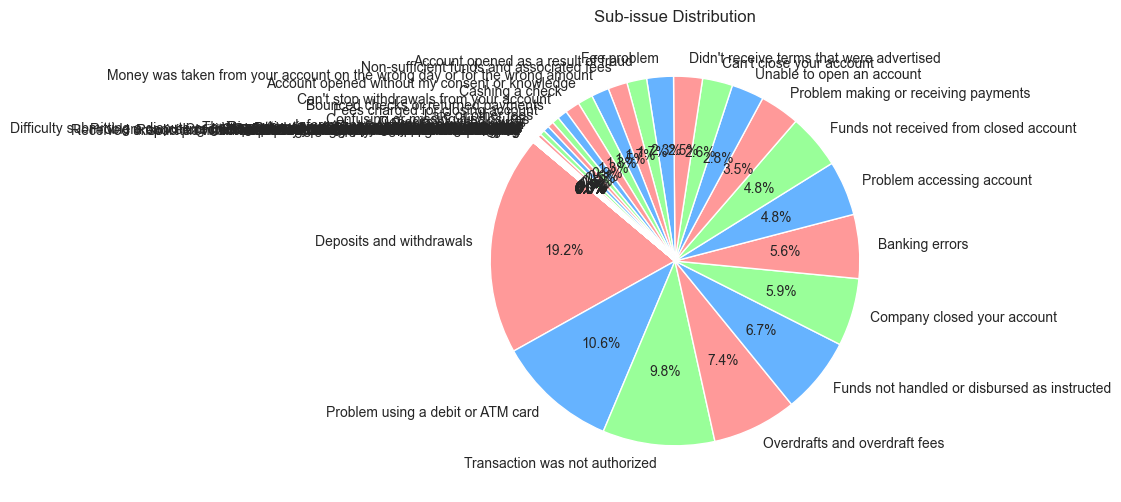

In [81]:
# 2. Check the distribution (returns frequencies of each unique category)
distribution = df["Sub-issue"].value_counts()
print("Data Distribution:\n", distribution)

# 3. Draw the pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    distribution,
    labels=distribution.index,
    autopct="%1.1f%%",  # Displays percentages automatically
    startangle=140,  # Rotates the start point for a cleaner look
    colors=["#ff9999", "#66b3ff", "#99ff99"],  # Optional custom colors
)

plt.title("Sub-issue Distribution")
plt.show()

In [83]:
# Conditions
conditions = [
    (df["Sub-issue"] == "Deposits and withdrawals"),
    (df["Sub-issue"] == "Problem using a debit or ATM card"),
    (df["Sub-issue"] == "Transaction was not authorized"),
    (df["Sub-issue"] == "Overdrafts and overdraft fees"),
    (df["Sub-issue"] == "Funds not handled or disbursed as instructed"),
    (df["Sub-issue"] == "Company closed your account"),
    (df["Sub-issue"] == "Banking errors"),
    (df["Sub-issue"] == "Problem accessing account"),
    (df["Sub-issue"] == "Funds not received from closed account"),
    (df["Sub-issue"] == "Problem making or receiving payments"),
    (df["Sub-issue"] == "Unable to open an account"),
    (df["Sub-issue"] == "Can't close your account"),
    (df["Sub-issue"] == "Didn't receive terms that were advertised"),
    (df["Sub-issue"] == "Fee problem"),
    (df["Sub-issue"] == "Account opened as a result of fraud"),
]

# Categories to assign
categories = ["Deposits and withdrawals", "Problem using a debit or ATM card", "Transaction was not authorized", "Overdrafts and overdraft fees", "Funds not handled or disbursed as instructed", "Company closed your account", "Banking errors", "Problem accessing account", "Funds not received from closed account", "Problem making or receiving payments", "Unable to open an account", "Can't close your account", "Didn't receive terms that were advertised", "Fee problem", "Account opened as a result of fraud"]

# Define new column variable based on categories
df["SubIssues_Group"] = np.select(conditions, categories, default="Others")
print(df)

       Date received                      Product       Sub-product  \
0            2020-04  Checking or savings account  Checking account   
1            2024-04  Checking or savings account  Checking account   
2            2020-07  Checking or savings account  Checking account   
3            2019-05  Checking or savings account  Checking account   
4            2023-12  Checking or savings account  Checking account   
...              ...                          ...               ...   
176937       2025-09  Checking or savings account  Checking account   
176938       2023-09  Checking or savings account  Checking account   
176939       2025-05  Checking or savings account  Checking account   
176940       2025-03  Checking or savings account  Checking account   
176941       2024-03  Checking or savings account  Checking account   

                                                    Issue  \
0                                     Managing an account   
1       Problem with a le

Data Distribution:
 SubIssues_Group
Deposits and withdrawals                        33979
Problem using a debit or ATM card               18665
Transaction was not authorized                  17344
Others                                          17262
Overdrafts and overdraft fees                   13075
Funds not handled or disbursed as instructed    11810
Company closed your account                     10486
Banking errors                                   9890
Problem accessing account                        8478
Funds not received from closed account           8471
Problem making or receiving payments             6148
Unable to open an account                        5028
Can't close your account                         4651
Didn't receive terms that were advertised        4463
Fee problem                                      4131
Account opened as a result of fraud              3061
Name: count, dtype: int64


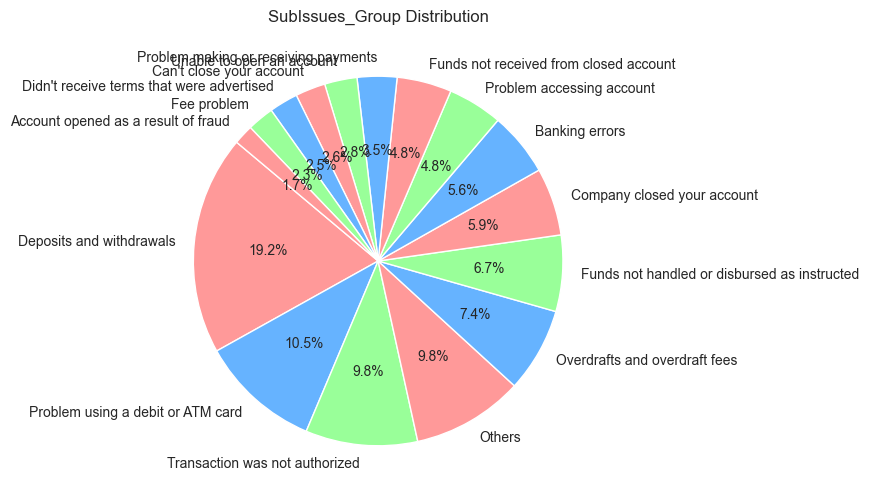

In [84]:
# 2. Check the distribution (returns frequencies of each unique category)
distribution = df["SubIssues_Group"].value_counts()
print("Data Distribution:\n", distribution)

# 3. Draw the pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    distribution,
    labels=distribution.index,
    autopct="%1.1f%%",  # Displays percentages automatically
    startangle=140,  # Rotates the start point for a cleaner look
    colors=["#ff9999", "#66b3ff", "#99ff99"],  # Optional custom colors
)

plt.title("SubIssues_Group Distribution")
plt.show()

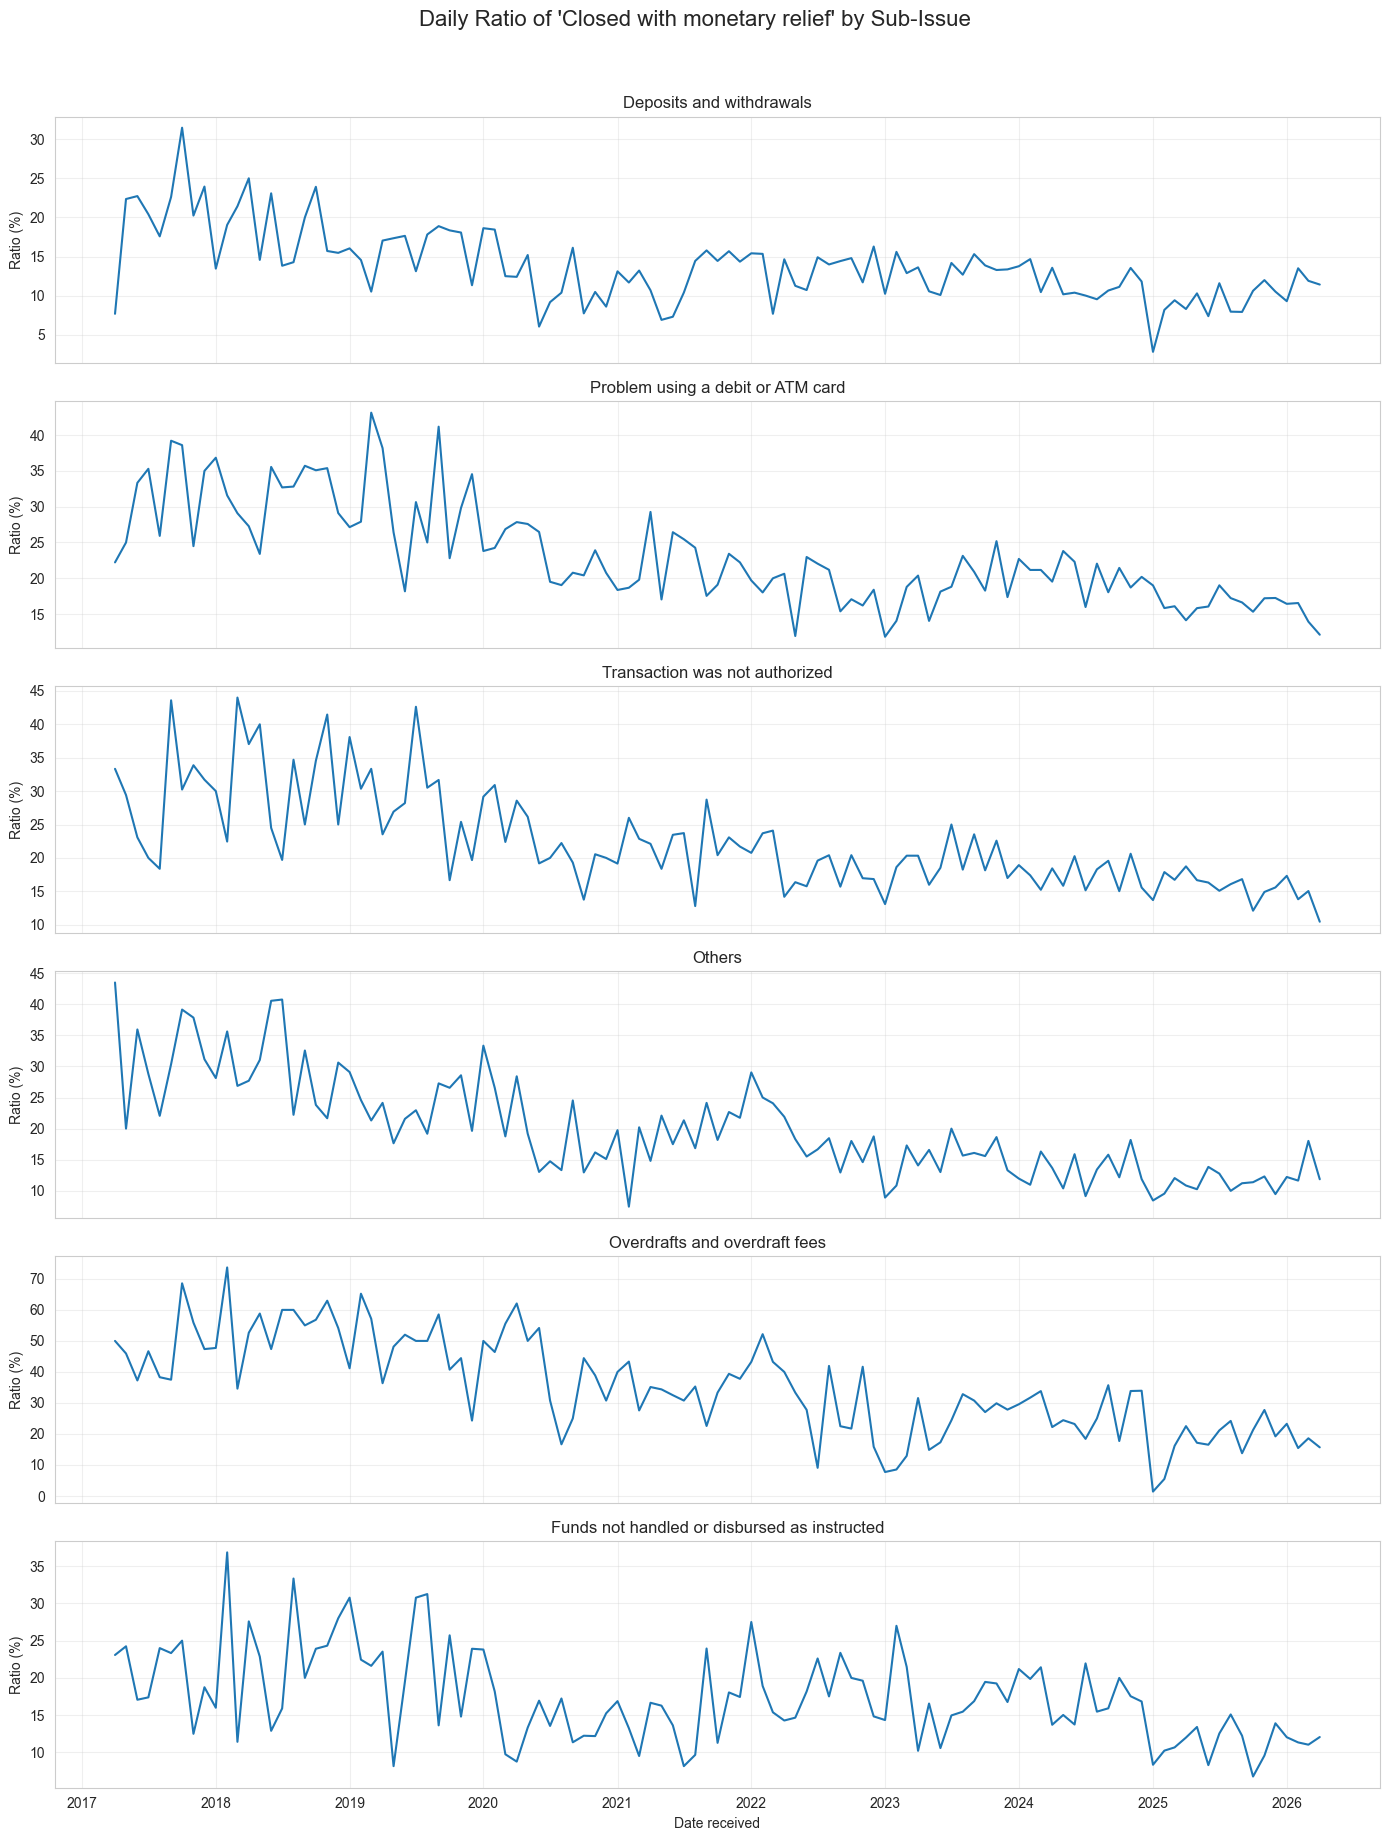

In [86]:
"# 2. Ratio by Issue over time",
subissues = df['SubIssues_Group'].value_counts().index[:6]  # Top 6 issues for clarity",
fig, axes = plt.subplots(len(subissues), 1, figsize=(14, 3 * len(subissues)), sharex=True)

for i, issue in enumerate(subissues):
    sub = df[df['SubIssues_Group'] == issue]
    daily = sub.groupby('Date received').agg(
    total_count = ('Company response to consumer', 'count'),
    closed_monetary = ('Company response to consumer', 
                       lambda x: (x == 'Closed with monetary relief').sum()))
    daily['ratio'] = daily['closed_monetary'] / daily['total_count'] * 100
    axes[i].plot(daily.index.to_timestamp(), daily['ratio'], label=issue, color='tab:blue')
    axes[i].set_ylabel('Ratio (%)')
    axes[i].set_title(f"{issue}")
    axes[i].grid(True, alpha=0.3)
    axes[-1].set_xlabel('Date received')
    
plt.suptitle("Daily Ratio of 'Closed with monetary relief' by Sub-Issue", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

### Response Timely

In [95]:
# 1. Overall ratio by date
# Ensure date is datetime

daily = df.groupby('Date received').agg(
    total_count = ('Timely response?', 'count'),
    timely_response = ('Timely response?', lambda x: (x == 'Yes').sum())
)
daily['ratio'] = daily['timely_response'] / daily['total_count'] * 100


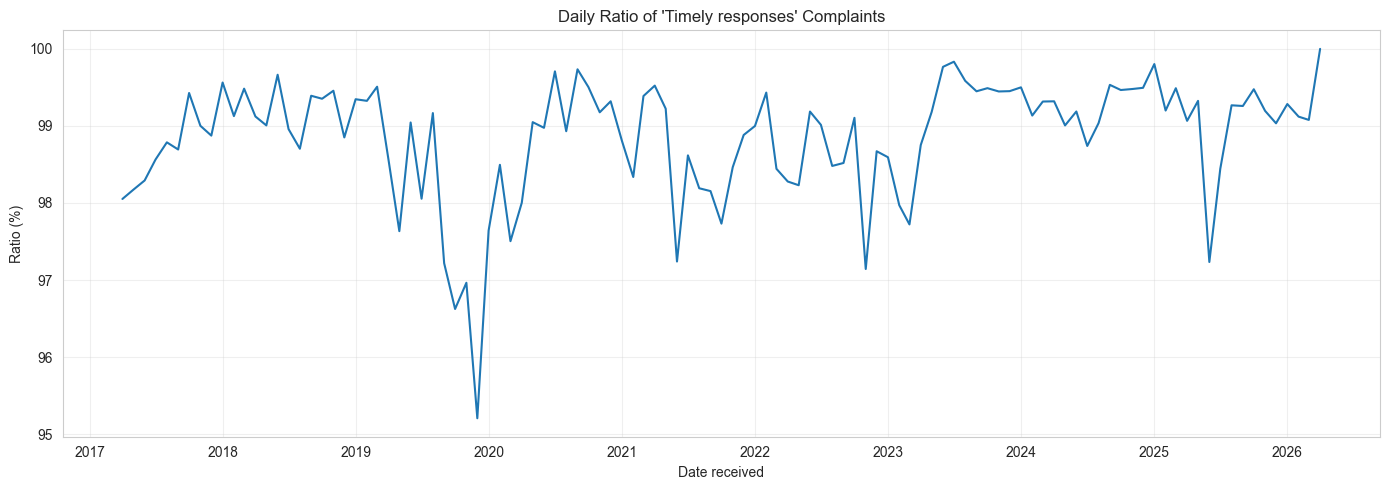

In [96]:
plt.figure(figsize=(14, 5))
plt.plot(daily.index.to_timestamp(), daily['ratio'], label="% Timely responses", color='tab:blue')
plt.ylabel('Ratio (%)')
plt.xlabel('Date received')
plt.title("Daily Ratio of 'Timely responses' Complaints")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

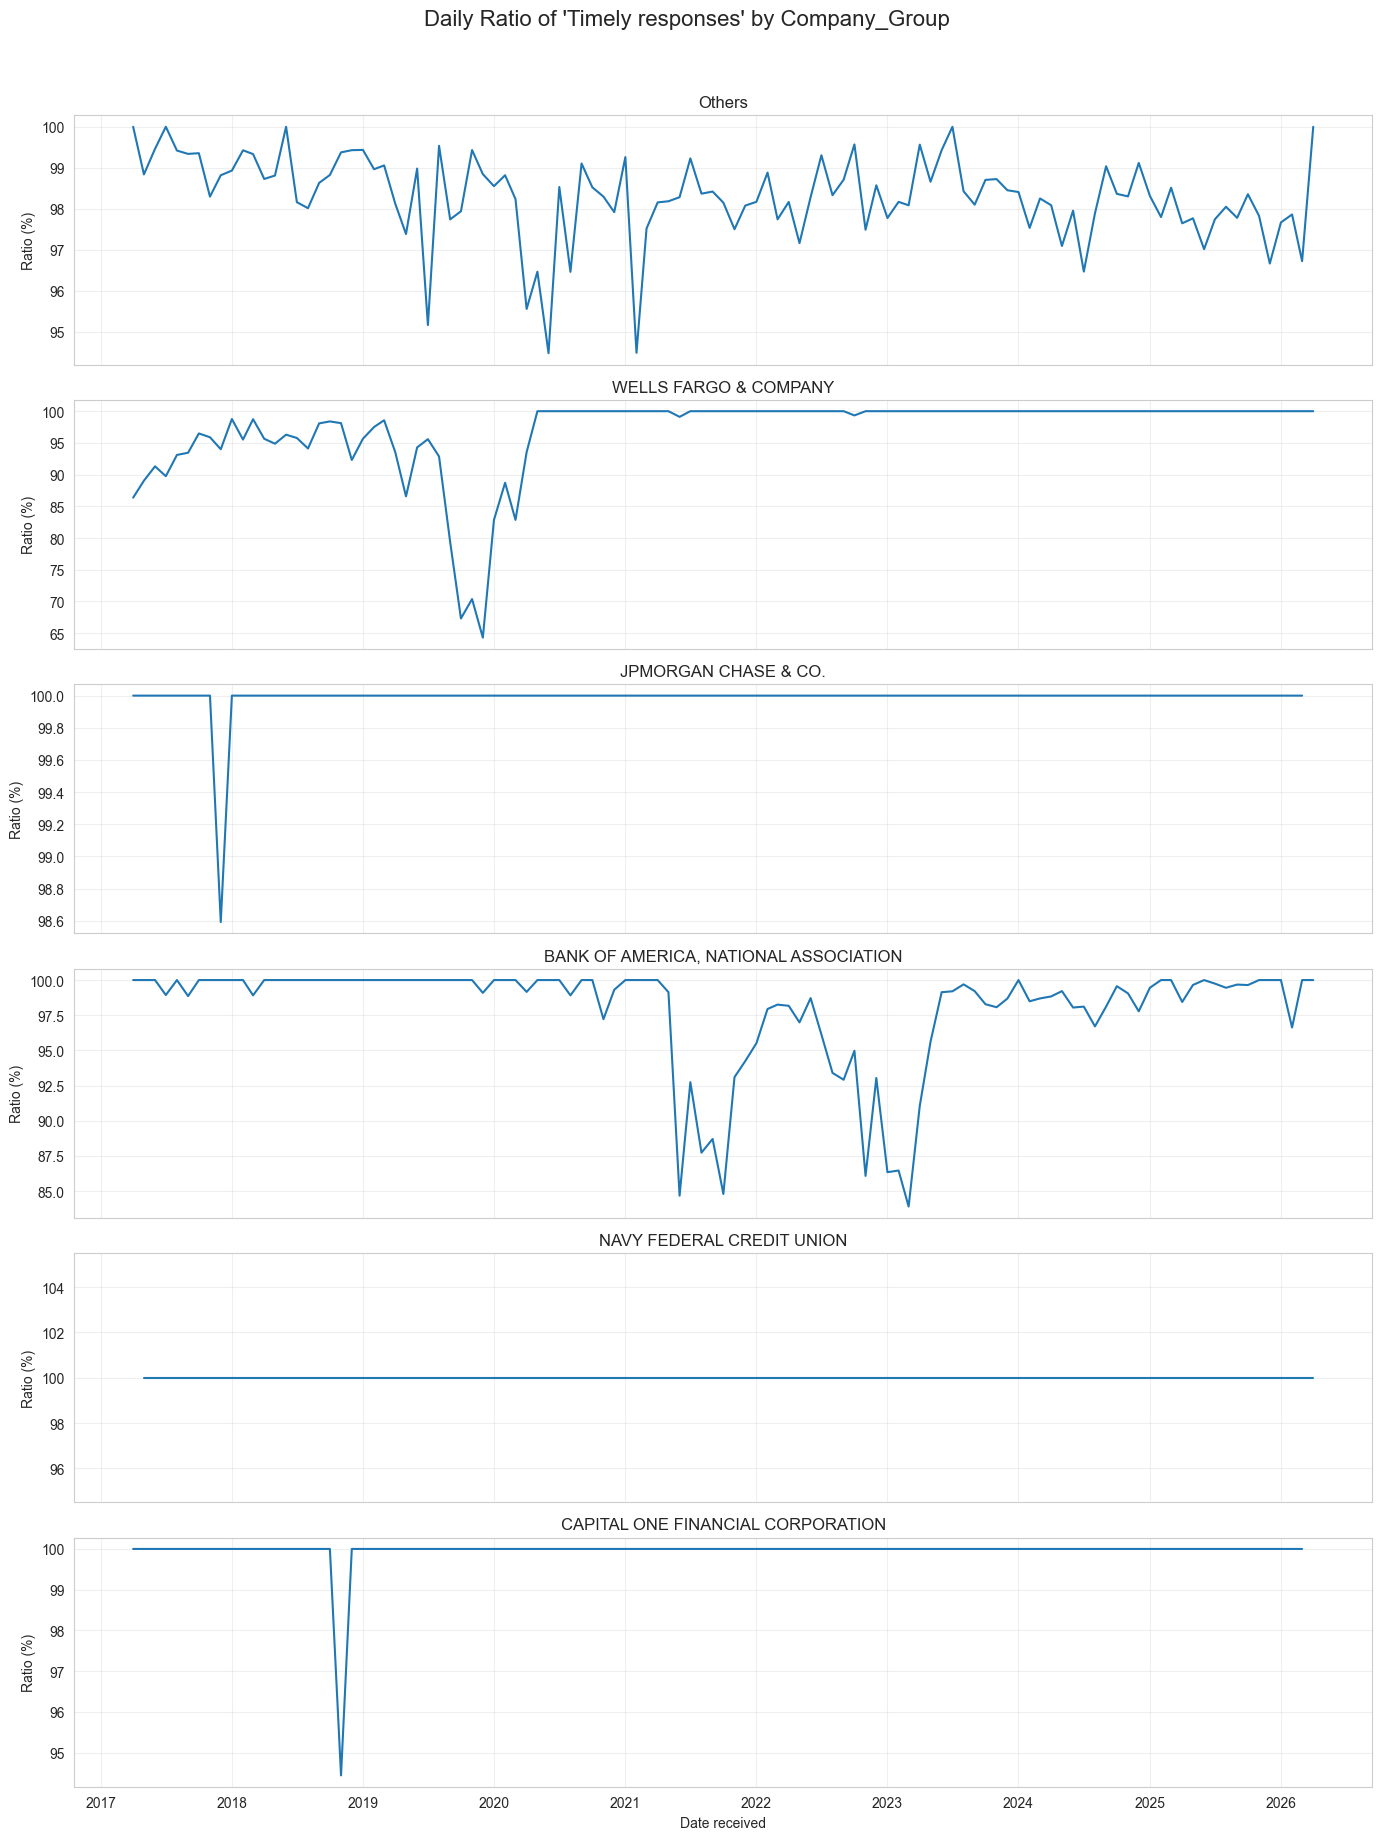

In [100]:
"# 2. Ratio by Timely Response over time",
companies = df['Company_Group'].value_counts().index[:6]  # Top 6 companies for clarity",
fig, axes = plt.subplots(len(companies), 1, figsize=(14, 3 * len(companies)), sharex=True)

for i, company in enumerate(companies):
    sub = df[df['Company_Group'] == company]
    daily = sub.groupby('Date received').agg(
    total_count = ('Timely response?', 'count'),
    timely_response = ('Timely response?', lambda x: (x == 'Yes').sum()))
    daily['ratio'] = daily['timely_response'] / daily['total_count'] * 100
    axes[i].plot(daily.index.to_timestamp(), daily['ratio'], label=company, color='tab:blue')
    axes[i].set_ylabel('Ratio (%)')
    axes[i].set_title(f"{company}")
    axes[i].grid(True, alpha=0.3)
    axes[-1].set_xlabel('Date received')
    
plt.suptitle("Daily Ratio of 'Timely responses' by Company_Group", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

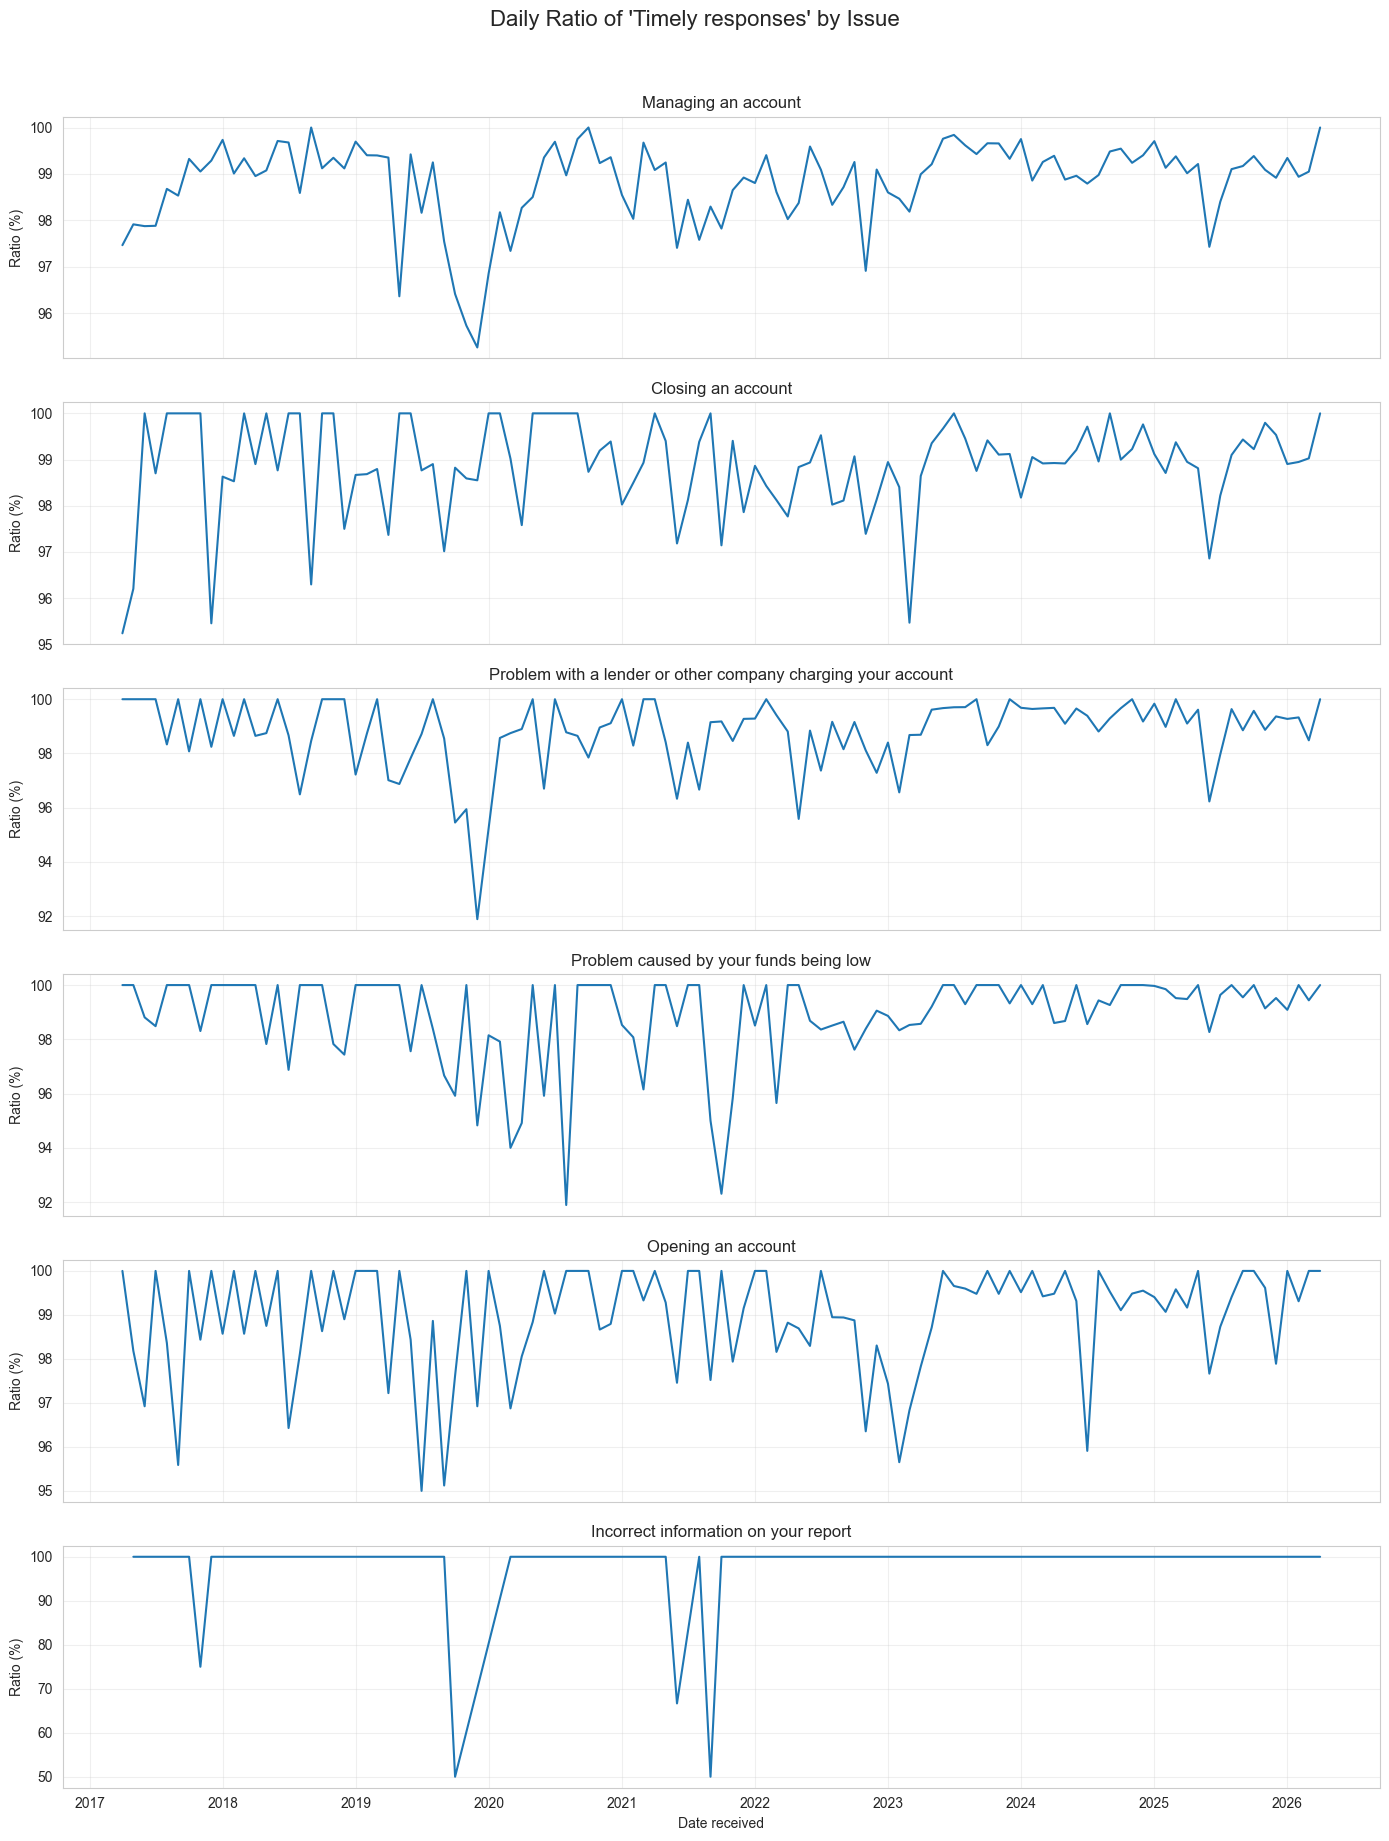

In [101]:
"# 2. Ratio by Timely Response over time",
issues = df['Issue'].value_counts().index[:6]  # Top 6 issues for clarity",
fig, axes = plt.subplots(len(issues), 1, figsize=(14, 3 * len(issues)), sharex=True)

for i, issue in enumerate(issues):
    sub = df[df['Issue'] == issue]
    daily = sub.groupby('Date received').agg(
    total_count = ('Timely response?', 'count'),
    timely_response = ('Timely response?', lambda x: (x == 'Yes').sum()))
    daily['ratio'] = daily['timely_response'] / daily['total_count'] * 100
    axes[i].plot(daily.index.to_timestamp(), daily['ratio'], label=issue, color='tab:blue')
    axes[i].set_ylabel('Ratio (%)')
    axes[i].set_title(f"{issue}")
    axes[i].grid(True, alpha=0.3)
    axes[-1].set_xlabel('Date received')
    
plt.suptitle("Daily Ratio of 'Timely responses' by Issue", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

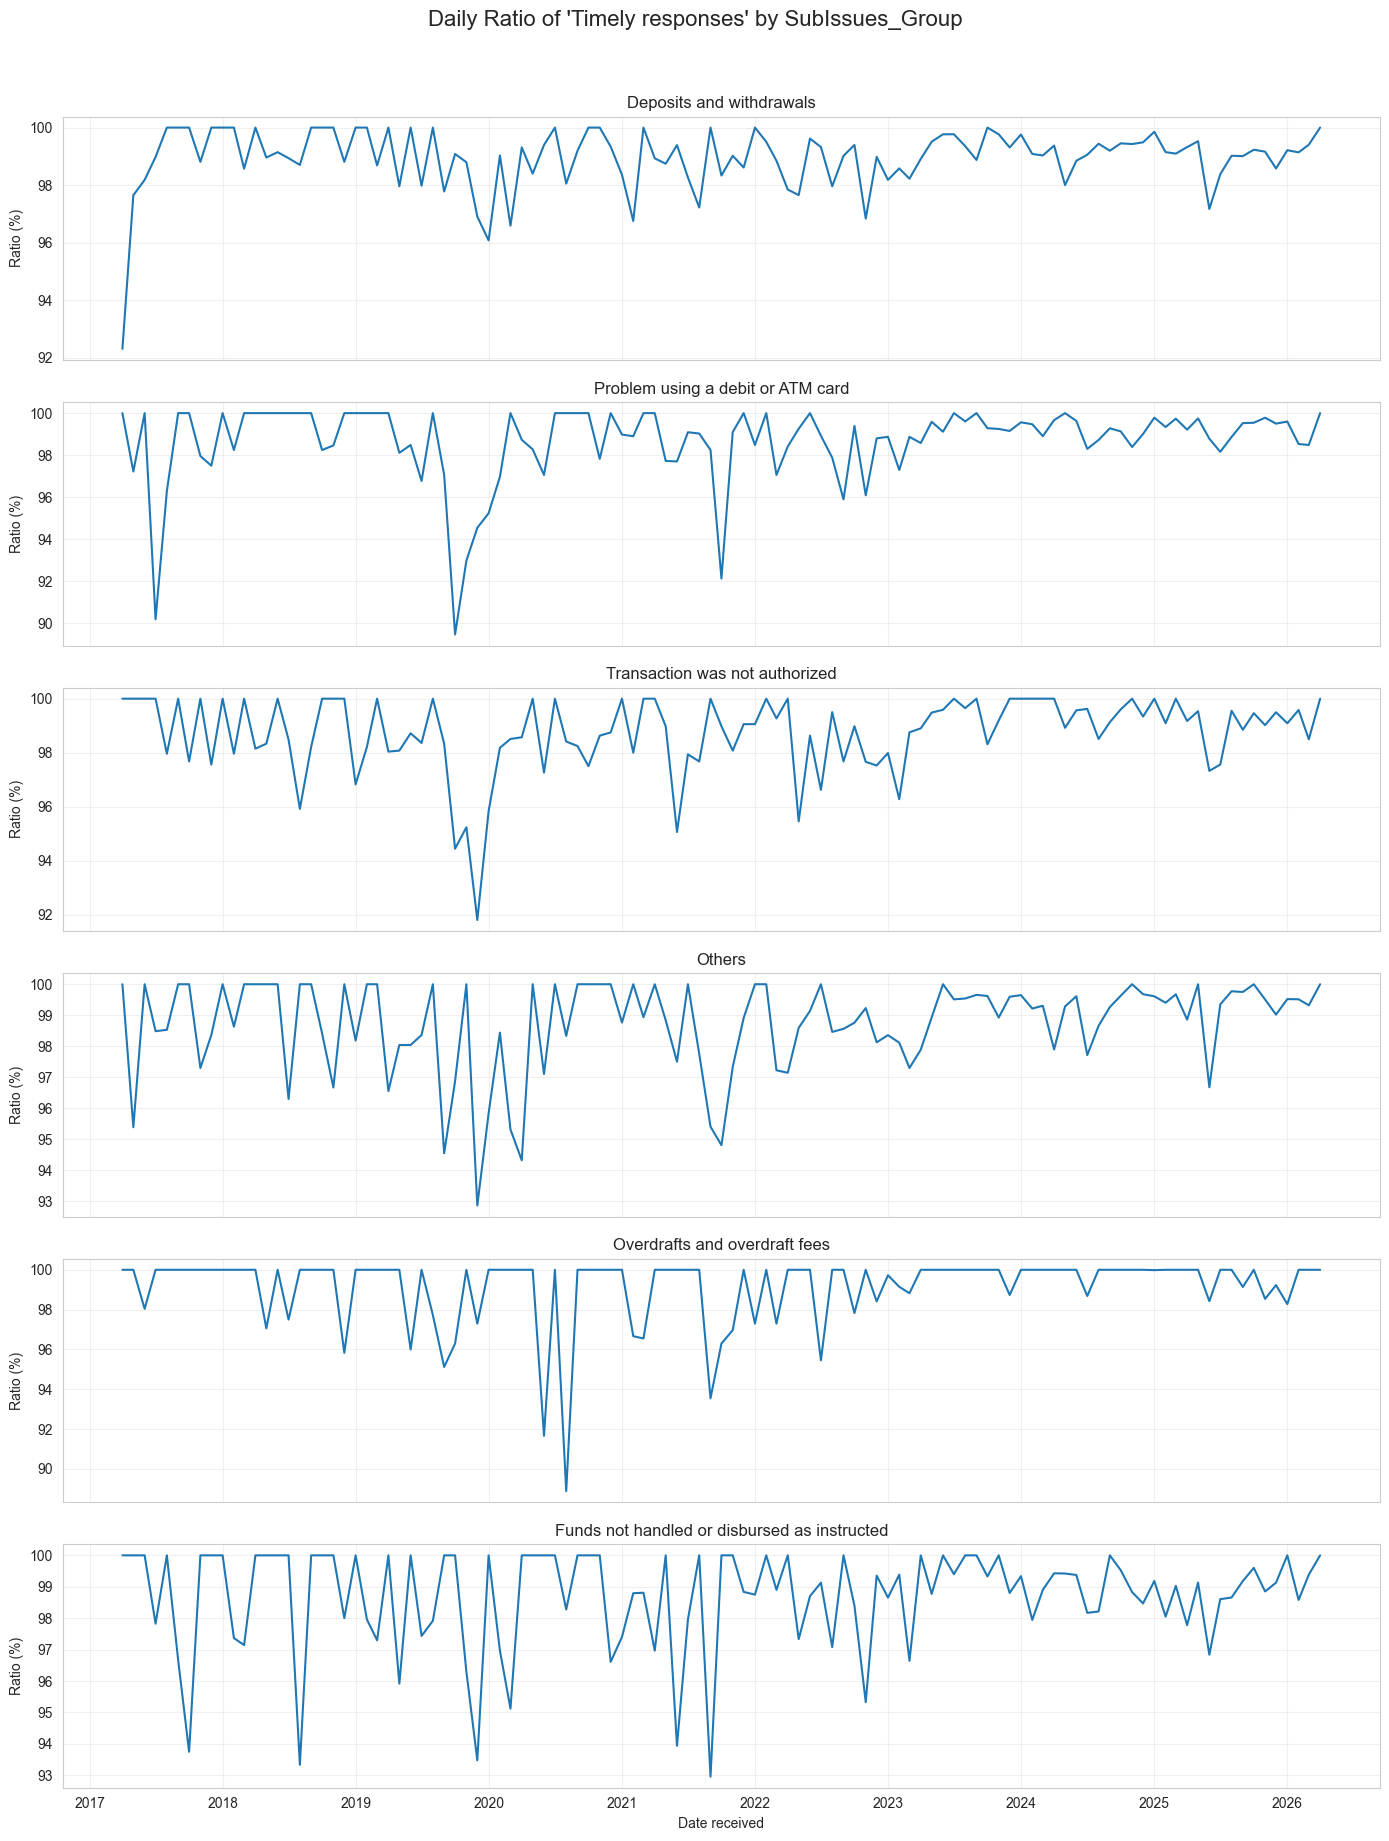

In [102]:
"# 2. Ratio by Timely Response over time",
subissues = df['SubIssues_Group'].value_counts().index[:6]  # Top 6 issues for clarity",
fig, axes = plt.subplots(len(subissues), 1, figsize=(14, 3 * len(subissues)), sharex=True)

for i, issue in enumerate(subissues):
    sub = df[df['SubIssues_Group'] == issue]
    daily = sub.groupby('Date received').agg(
    total_count = ('Timely response?', 'count'),
    timely_response = ('Timely response?', lambda x: (x == 'Yes').sum()))
    daily['ratio'] = daily['timely_response'] / daily['total_count'] * 100
    axes[i].plot(daily.index.to_timestamp(), daily['ratio'], label=issue, color='tab:blue')
    axes[i].set_ylabel('Ratio (%)')
    axes[i].set_title(f"{issue}")
    axes[i].grid(True, alpha=0.3)
    axes[-1].set_xlabel('Date received')
    
plt.suptitle("Daily Ratio of 'Timely responses' by SubIssues_Group", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

### BackUp Below

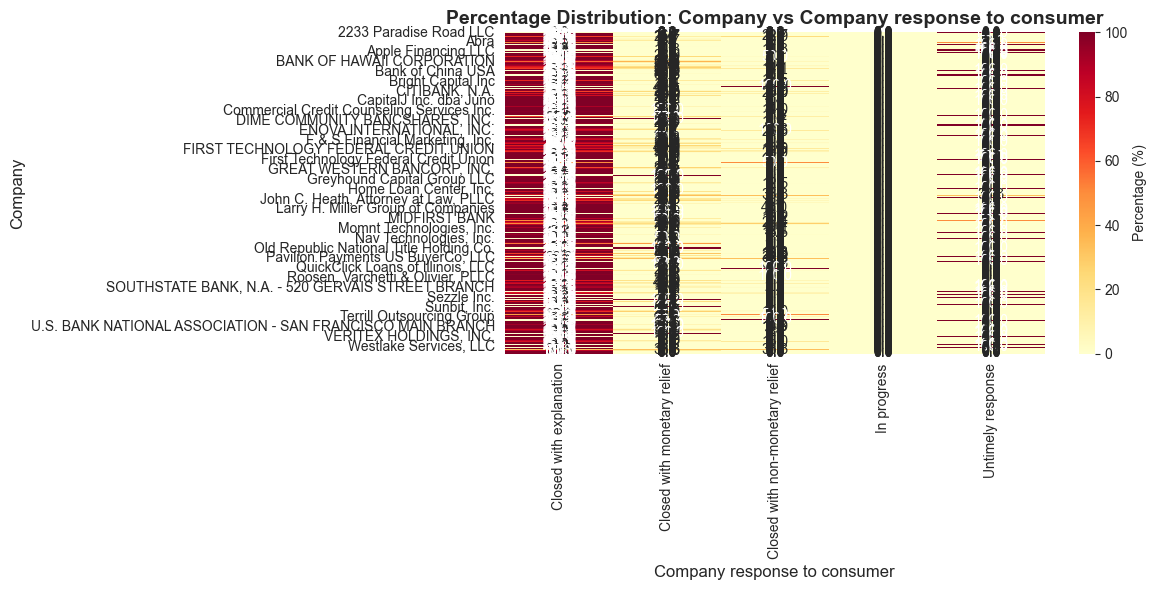


Statistical Summary for top 5 fields:
input_field  cramers_v       p_value          chi2  categories
    Company   0.510408  0.000000e+00 184385.034715         687
  Sub-issue   0.123772  0.000000e+00  10835.280387          50
      Issue   0.058128  0.000000e+00   2391.481168          13
      State   0.037035  5.820331e-86    962.591446          62
Sub-product   0.032130 1.402964e-109    547.877135           4


In [10]:
# Heatmap for top field
top_field = results_company_response.iloc[0]['input_field']
ct = pd.crosstab(df[top_field], df[target])
ct_pct = pd.crosstab(df[top_field], df[target], normalize='index') * 100

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(ct_pct, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Percentage (%)'}, ax=ax)
ax.set_title(f'Percentage Distribution: {top_field} vs {target}', fontsize=14, fontweight='bold')
ax.set_xlabel(target, fontsize=12)
ax.set_ylabel(top_field, fontsize=12)
plt.tight_layout()
plt.savefig('company_response_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nStatistical Summary for top 5 fields:")
print(results_company_response[['input_field', 'cramers_v', 'p_value', 'chi2', 'categories']].head(5).to_string(index=False))


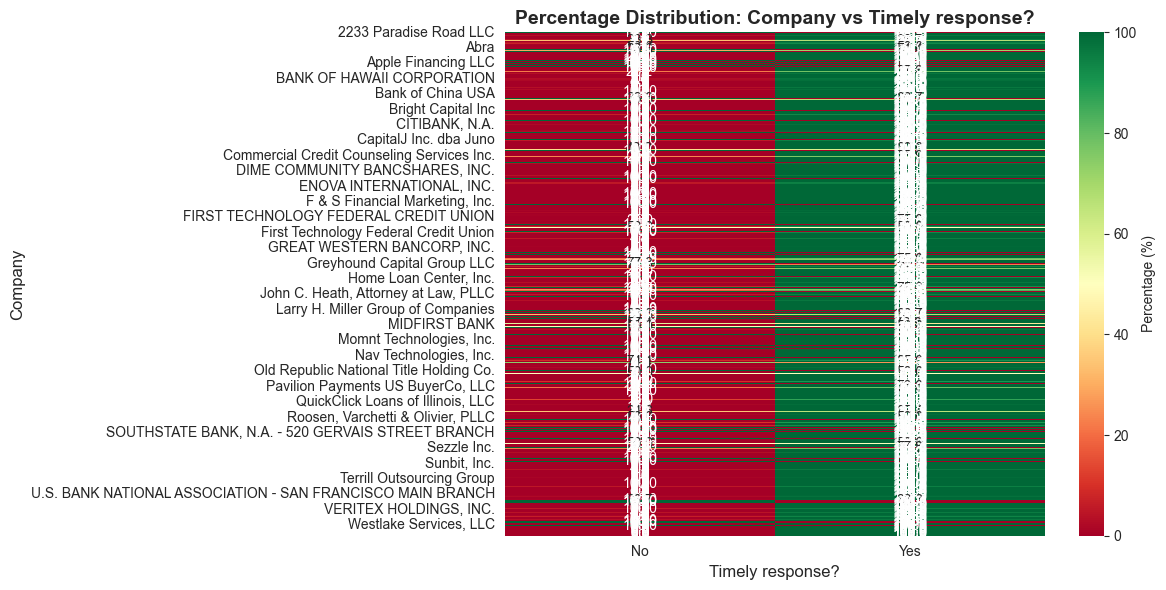


Statistical Summary for top 5 fields:
input_field  cramers_v      p_value         chi2  categories
    Company   0.387633 0.000000e+00 26587.121599         687
Sub-product   0.035493 4.826133e-48   222.863971           4
  Sub-issue   0.033769 2.043953e-20   201.643433          50
      Issue   0.020017 2.174362e-10    70.898298          13
      State   0.018789 4.423727e-01    61.939539          62


In [12]:
# Heatmap for top field
top_field = results_timely.iloc[0]['input_field']
ct_pct = pd.crosstab(df[top_field], df[target], normalize='index') * 100

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(ct_pct, annot=True, fmt='.1f', cmap='RdYlGn', cbar_kws={'label': 'Percentage (%)'}, ax=ax)
ax.set_title(f'Percentage Distribution: {top_field} vs {target}', fontsize=14, fontweight='bold')
ax.set_xlabel(target, fontsize=12)
ax.set_ylabel(top_field, fontsize=12)
plt.tight_layout()
plt.savefig('timely_response_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nStatistical Summary for top 5 fields:")
print(results_timely[['input_field', 'cramers_v', 'p_value', 'chi2', 'categories']].head(5).to_string(index=False))


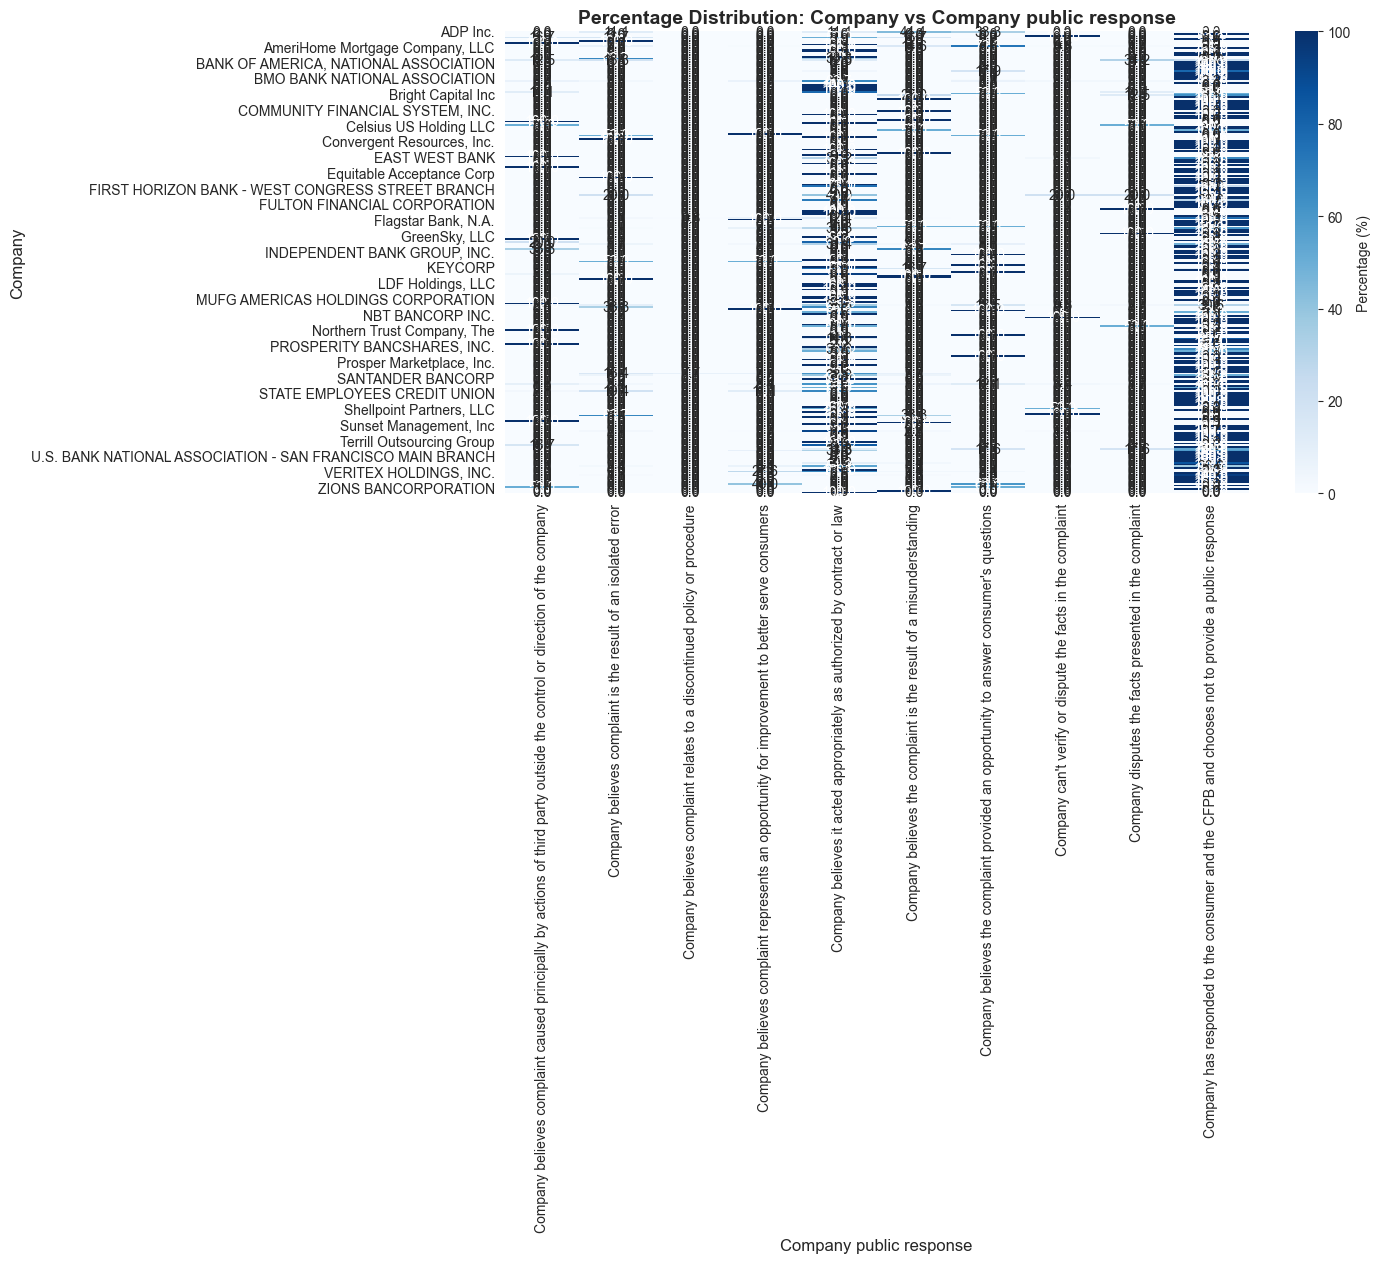


Statistical Summary for top 5 fields:
input_field  cramers_v       p_value          chi2  categories
    Company   0.564522  0.000000e+00 254836.813757         264
  Sub-issue   0.172557  0.000000e+00  23792.048760          50
      Issue   0.154449  0.000000e+00  19075.307857          12
      State   0.085263  0.000000e+00   5766.211850          60
Sub-product   0.058151 1.875097e-172    901.130513           4


In [14]:
# Heatmap for top field
top_field = results_public.iloc[0]['input_field']
ct_pct = pd.crosstab(df[top_field], df[target], normalize='index') * 100

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(ct_pct, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': 'Percentage (%)'}, ax=ax)
ax.set_title(f'Percentage Distribution: {top_field} vs {target}', fontsize=14, fontweight='bold')
ax.set_xlabel(target, fontsize=12)
ax.set_ylabel(top_field, fontsize=12)
plt.tight_layout()
plt.savefig('public_response_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nStatistical Summary for top 5 fields:")
print(results_public[['input_field', 'cramers_v', 'p_value', 'chi2', 'categories']].head(5).to_string(index=False))



COMPARATIVE ANALYSIS: Strongest Predictors Across All Target Fields

Overall Association Strength by Field:
      Field  Company Response Cramers V  Company Response p-value  Timely Response Cramers V  Timely Response p-value  Public Response Cramers V  Public Response p-value
Sub-product                    0.032130             1.402964e-109                   0.035493             4.826133e-48                   0.058151            1.875097e-172
      Issue                    0.058128              0.000000e+00                   0.020017             2.174362e-10                   0.154449             0.000000e+00
  Sub-issue                    0.123772              0.000000e+00                   0.033769             2.043953e-20                   0.172557             0.000000e+00
    Company                    0.510408              0.000000e+00                   0.387633             0.000000e+00                   0.564522             0.000000e+00
      State                    0.037035  

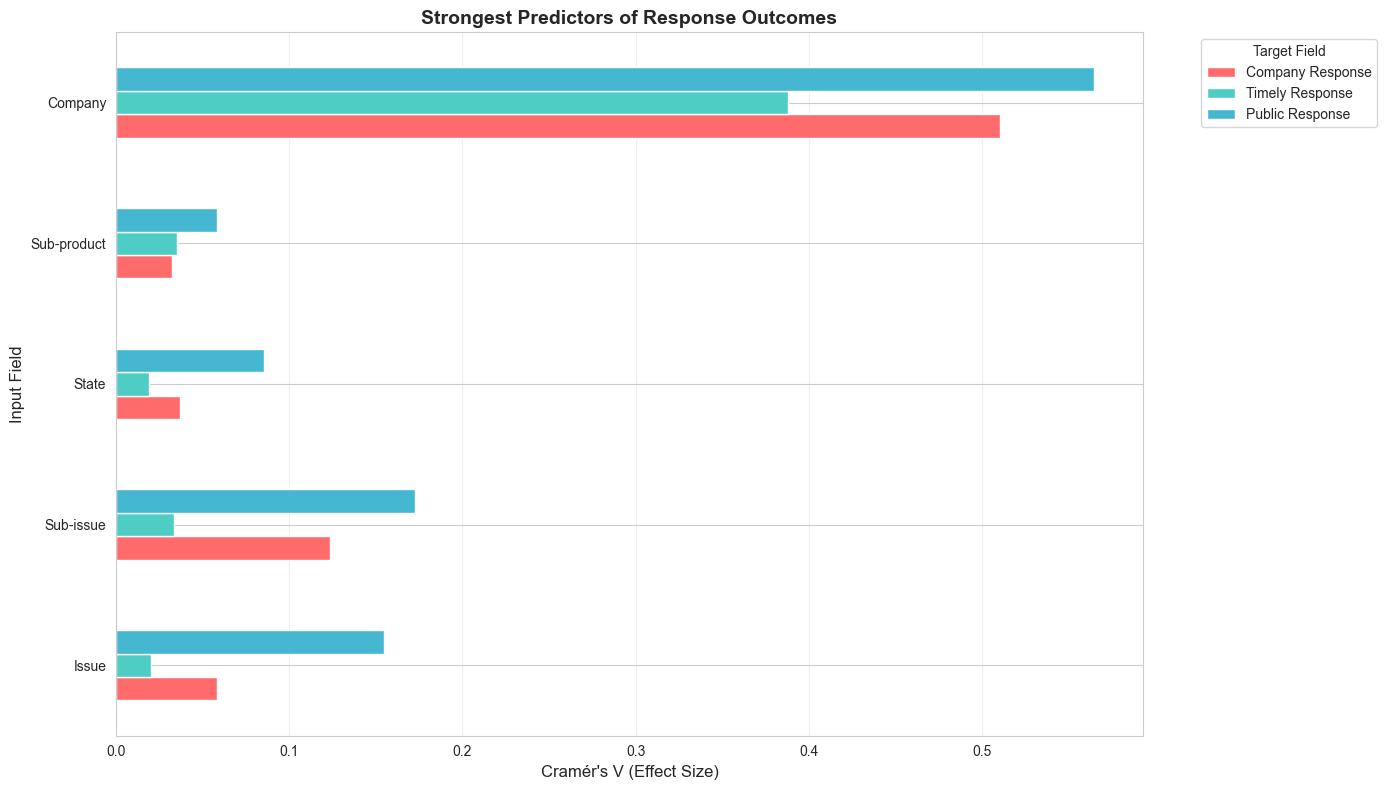

In [16]:
print(f"\n{'='*80}")
print("COMPARATIVE ANALYSIS: Strongest Predictors Across All Target Fields")
print(f"{'='*80}\n")

# Create comparison dataframe
comparison_data = []
for field in input_fields:
    comp_response = results_company_response[results_company_response['input_field'] == field]
    timely = results_timely[results_timely['input_field'] == field]
    public = results_public[results_public['input_field'] == field]
    
    if not comp_response.empty:
        comparison_data.append({
            'Field': field,
            'Company Response Cramers V': comp_response['cramers_v'].values[0],
            'Company Response p-value': comp_response['p_value'].values[0],
        })
    
    if not timely.empty and comparison_data and comparison_data[-1]['Field'] == field:
        comparison_data[-1]['Timely Response Cramers V'] = timely['cramers_v'].values[0]
        comparison_data[-1]['Timely Response p-value'] = timely['p_value'].values[0]
    
    if not public.empty and comparison_data and comparison_data[-1]['Field'] == field:
        comparison_data[-1]['Public Response Cramers V'] = public['cramers_v'].values[0]
        comparison_data[-1]['Public Response p-value'] = public['p_value'].values[0]

comparison_df = pd.DataFrame(comparison_data)

# Fill NaN with empty string for display
comparison_df = comparison_df.fillna('')

print("Overall Association Strength by Field:")
print(comparison_df.to_string(index=False))

# Create a combined ranking
fig, ax = plt.subplots(figsize=(14, 8))

# Prepare data for stacked bar chart
top_fields_overall = list(set(
    results_company_response.head(5)['input_field'].tolist() +
    results_timely.head(5)['input_field'].tolist() +
    results_public.head(5)['input_field'].tolist()
))[:10]

cramers_v_values = []
for field in top_fields_overall:
    comp_resp = results_company_response[results_company_response['input_field'] == field]['cramers_v'].values
    timely_resp = results_timely[results_timely['input_field'] == field]['cramers_v'].values
    public_resp = results_public[results_public['input_field'] == field]['cramers_v'].values
    
    cramers_v_values.append({
        'Field': field,
        'Company Response': comp_resp[0] if len(comp_resp) > 0 else 0,
        'Timely Response': timely_resp[0] if len(timely_resp) > 0 else 0,
        'Public Response': public_resp[0] if len(public_resp) > 0 else 0,
    })

cramers_df = pd.DataFrame(cramers_v_values).set_index('Field')
cramers_df.plot(kind='barh', ax=ax, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax.set_xlabel("Cramér's V (Effect Size)", fontsize=12)
ax.set_ylabel('Input Field', fontsize=12)
ax.set_title("Strongest Predictors of Response Outcomes", fontsize=14, fontweight='bold')
ax.legend(title='Target Field', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('comparative_analysis.png', dpi=100, bbox_inches='tight')
plt.show()


In [19]:
print("\n" + "="*80)
print("KEY FINDINGS")
print("="*80 + "\n")

# Key finding 1: Company Response to Consumer
print("1. COMPANY RESPONSE TO CONSUMER")
print("-" * 40)
top_5_company = results_company_response.head(5)
for idx, row in top_5_company.iterrows():
    print(f"   • {row['input_field']:25} | Cramér's V: {row['cramers_v']:.4f} | p-value: {row['p_value']:.2e}")
print()

# Key finding 2: Timely Response
print("2. TIMELY RESPONSE")
print("-" * 40)
top_5_timely = results_timely.head(5)
for idx, row in top_5_timely.iterrows():
    print(f"   • {row['input_field']:25} | Cramér's V: {row['cramers_v']:.4f} | p-value: {row['p_value']:.2e}")
print()

# Key finding 3: Company Public Response
print("3. COMPANY PUBLIC RESPONSE")
print("-" * 40)
top_5_public = results_public.head(5)
for idx, row in top_5_public.iterrows():
    print(f"   • {row['input_field']:25} | Cramér's V: {row['cramers_v']:.4f} | p-value: {row['p_value']:.2e}")
print()

# Statistical interpretation
print("\nINTERPRETATION OF CRAMÉR'S V:")
print("-" * 40)
print("   0.0 - 0.1   : Negligible association")
print("   0.1 - 0.3   : Weak association")
print("   0.3 - 0.5   : Moderate association")
print("   0.5 - 1.0   : Strong association")
print()

# Count significant relationships
sig_company = len(results_company_response[results_company_response['p_value'] < 0.05])
sig_timely = len(results_timely[results_timely['p_value'] < 0.05])
sig_public = len(results_public[results_public['p_value'] < 0.05])

print("STATISTICALLY SIGNIFICANT RELATIONSHIPS (p < 0.05):")
print("-" * 40)
print(f"   • Company Response to Consumer: {sig_company}/{len(results_company_response)} fields")
print(f"   • Timely Response: {sig_timely}/{len(results_timely)} fields")
print(f"   • Company Public Response: {sig_public}/{len(results_public)} fields")
print()

# Strongest overall predictor
all_results = pd.concat([
    results_company_response.assign(target='Company Response'),
    results_timely.assign(target='Timely Response'),
    results_public.assign(target='Public Response')
])
strongest = all_results.nlargest(1, 'cramers_v').iloc[0]
print("STRONGEST OVERALL PREDICTOR:")
print("-" * 40)
print(f"   Field: {strongest['input_field']}")
print(f"   Target: {strongest['target']}")
print(f"   Cramér's V: {strongest['cramers_v']:.4f}")
print(f"   Chi-square: {strongest['chi2']:.2f}")
print(f"   p-value: {strongest['p_value']:.2e}")



KEY FINDINGS

1. COMPANY RESPONSE TO CONSUMER
----------------------------------------
   • Company                   | Cramér's V: 0.5104 | p-value: 0.00e+00
   • Sub-issue                 | Cramér's V: 0.1238 | p-value: 0.00e+00
   • Issue                     | Cramér's V: 0.0581 | p-value: 0.00e+00
   • State                     | Cramér's V: 0.0370 | p-value: 5.82e-86
   • Sub-product               | Cramér's V: 0.0321 | p-value: 1.40e-109

2. TIMELY RESPONSE
----------------------------------------
   • Company                   | Cramér's V: 0.3876 | p-value: 0.00e+00
   • Sub-product               | Cramér's V: 0.0355 | p-value: 4.83e-48
   • Sub-issue                 | Cramér's V: 0.0338 | p-value: 2.04e-20
   • Issue                     | Cramér's V: 0.0200 | p-value: 2.17e-10
   • State                     | Cramér's V: 0.0188 | p-value: 4.42e-01

3. COMPANY PUBLIC RESPONSE
----------------------------------------
   • Company                   | Cramér's V: 0.5645 | p-value

## Section 8: Comparative Summary

Comparison of strongest predictors across all three target fields



Analysis: Company public response

Top 10 associations with 'Company public response':
input_field          chi2       p_value  cramers_v
    Company 254836.813757  0.000000e+00   0.564522
  Sub-issue  23792.048760  0.000000e+00   0.172557
      Issue  19075.307857  0.000000e+00   0.154449
      State   5766.211850  0.000000e+00   0.085263
Sub-product    901.130513 1.875097e-172   0.058151


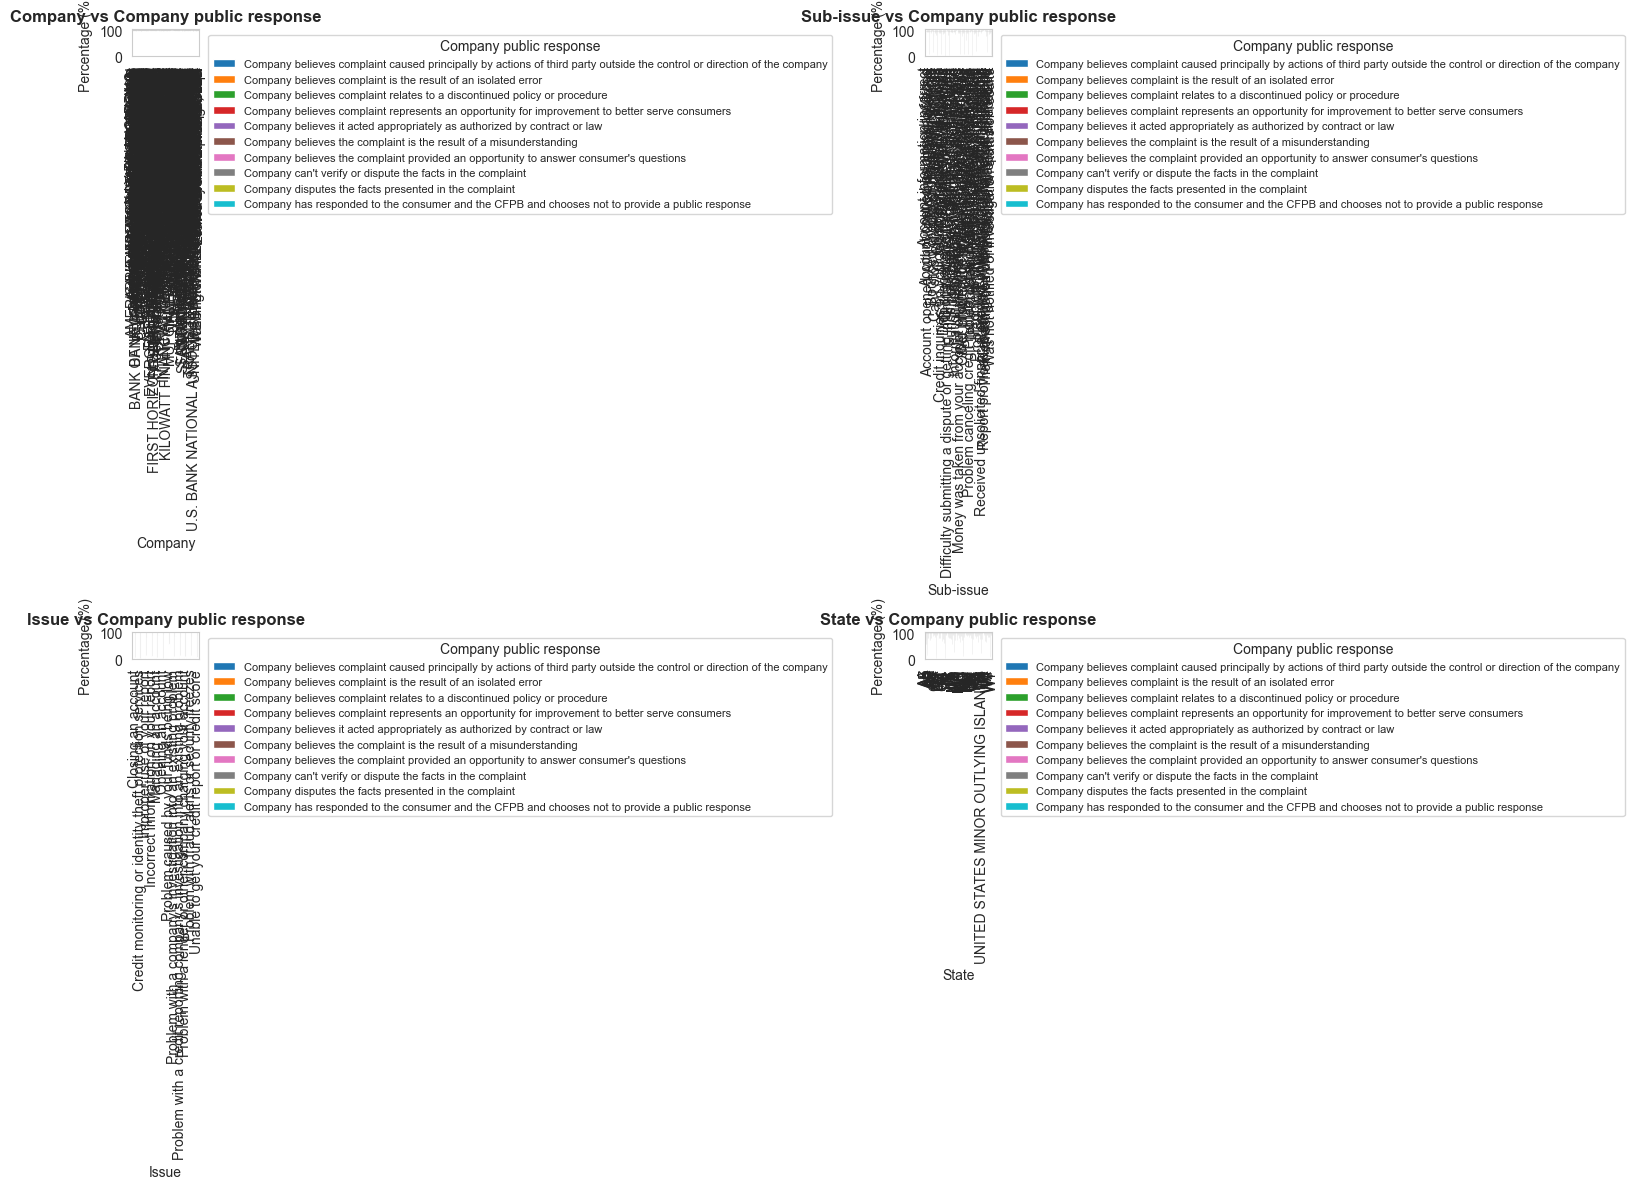

In [20]:
target = 'Company public response'
print(f"\n{'='*80}")
print(f"Analysis: {target}")
print(f"{'='*80}\n")

# Analyze all relationships
results_public = analyze_target_field(df, input_fields, target)
results_public = results_public.sort_values('cramers_v', ascending=False)

# Display top associations
print(f"Top 10 associations with '{target}':")
print(results_public[['input_field', 'chi2', 'p_value', 'cramers_v']].head(10).to_string(index=False))

# Visualization: Top fields
top_fields = results_public.head(8)['input_field'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for idx, field in enumerate(top_fields[:4]):
    ax = axes[idx // 2, idx % 2]
    ct_pct = pd.crosstab(df[field], df[target], normalize='index') * 100
    ct_pct.plot(kind='bar', ax=ax, stacked=False)
    ax.set_title(f'{field} vs {target}', fontsize=12, fontweight='bold')
    ax.set_xlabel(field, fontsize=10)
    ax.set_ylabel('Percentage (%)', fontsize=10)
    ax.legend(title=target, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('public_response_analysis.png', dpi=100, bbox_inches='tight')
plt.show()


## Section 7: Analysis - Company Public Response

Cross-tabulation and chi-square analysis for "Company public response" field



Analysis: Timely response?



Top 10 associations with 'Timely response?':
input_field         chi2      p_value  cramers_v
    Company 26587.121599 0.000000e+00   0.387633
Sub-product   222.863971 4.826133e-48   0.035493
  Sub-issue   201.643433 2.043953e-20   0.033769
      Issue    70.898298 2.174362e-10   0.020017
      State    61.939539 4.423727e-01   0.018789


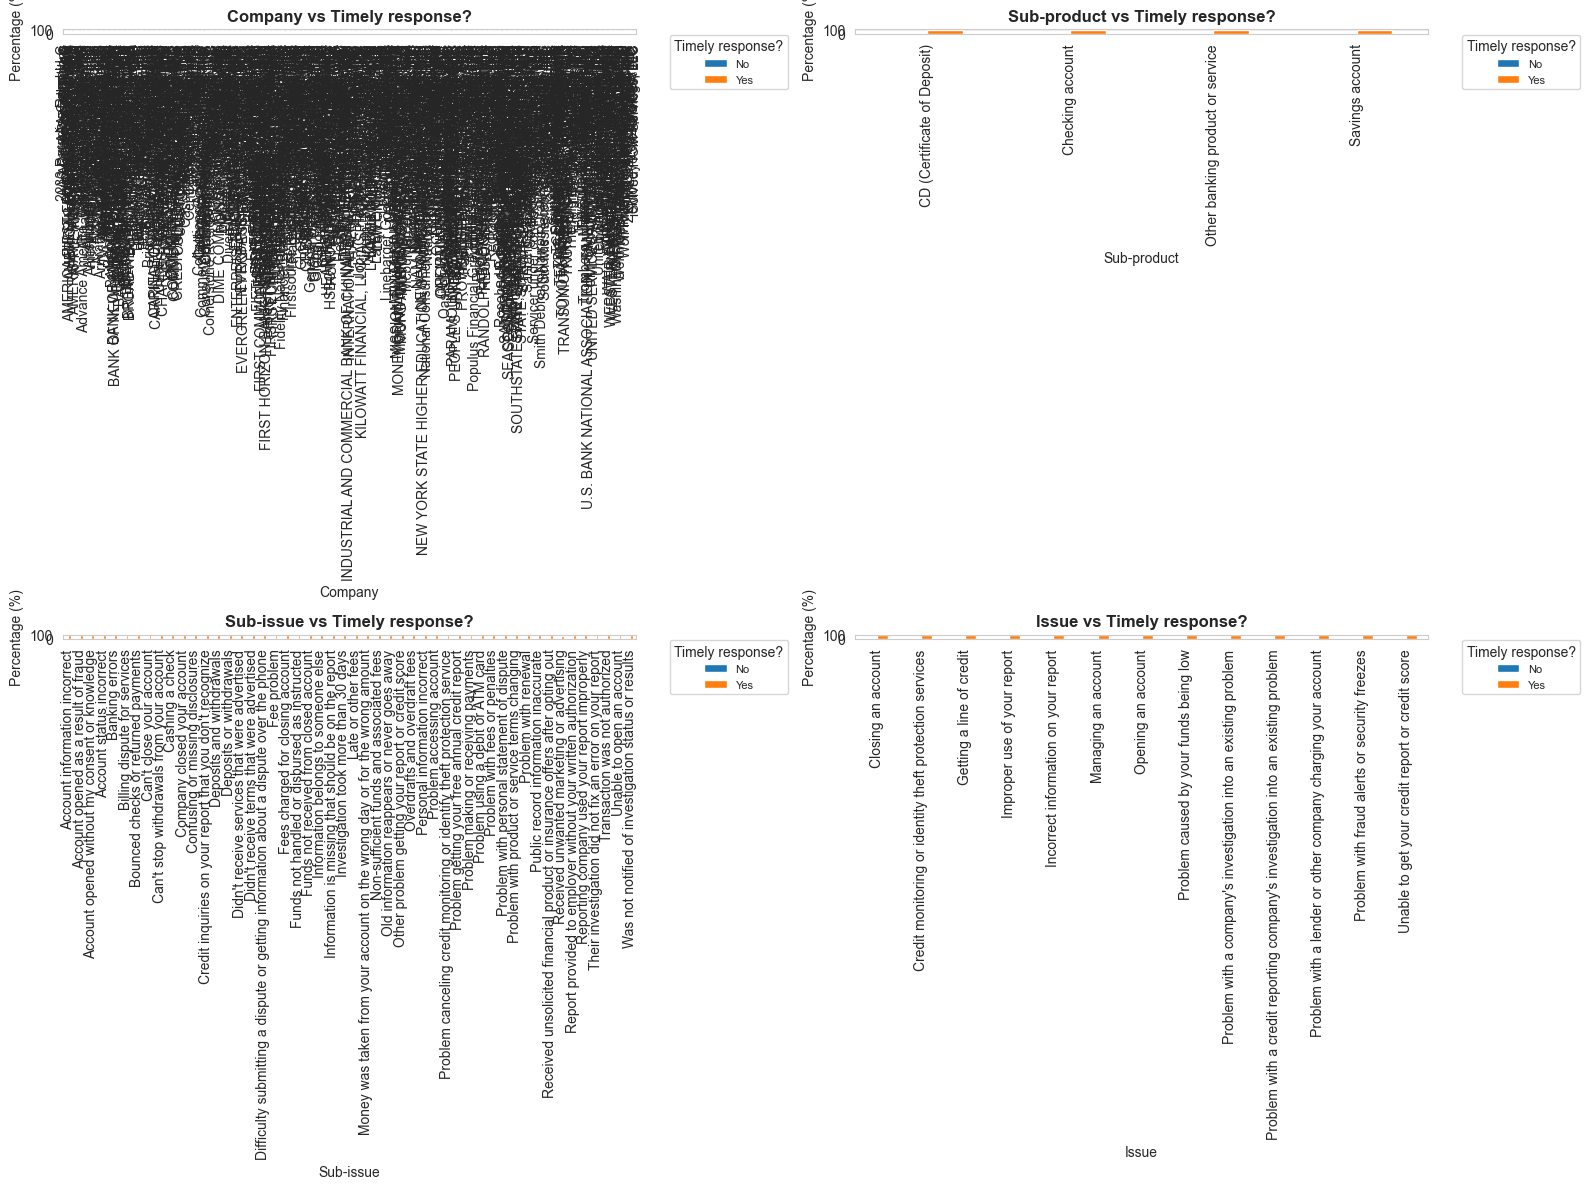

In [21]:
target = 'Timely response?'
print(f"\n{'='*80}")
print(f"Analysis: {target}")
print(f"{'='*80}\n")

# Analyze all relationships
results_timely = analyze_target_field(df, input_fields, target)
results_timely = results_timely.sort_values('cramers_v', ascending=False)

# Display top associations
print(f"Top 10 associations with '{target}':")
print(results_timely[['input_field', 'chi2', 'p_value', 'cramers_v']].head(10).to_string(index=False))

# Visualization: Top fields
top_fields = results_timely.head(8)['input_field'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for idx, field in enumerate(top_fields[:4]):
    ax = axes[idx // 2, idx % 2]
    ct_pct = pd.crosstab(df[field], df[target], normalize='index') * 100
    ct_pct.plot(kind='bar', ax=ax, stacked=False)
    ax.set_title(f'{field} vs {target}', fontsize=12, fontweight='bold')
    ax.set_xlabel(field, fontsize=10)
    ax.set_ylabel('Percentage (%)', fontsize=10)
    ax.legend(title=target, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('timely_response_analysis.png', dpi=100, bbox_inches='tight')
plt.show()


## Section 6: Analysis - Timely Response

Cross-tabulation and chi-square analysis for "Timely response?" field



Analysis: Company response to consumer

Top 10 associations with 'Company response to consumer':
input_field          chi2       p_value  cramers_v
    Company 184385.034715  0.000000e+00   0.510408
  Sub-issue  10835.280387  0.000000e+00   0.123772
      Issue   2391.481168  0.000000e+00   0.058128
      State    962.591446  5.820331e-86   0.037035
Sub-product    547.877135 1.402964e-109   0.032130


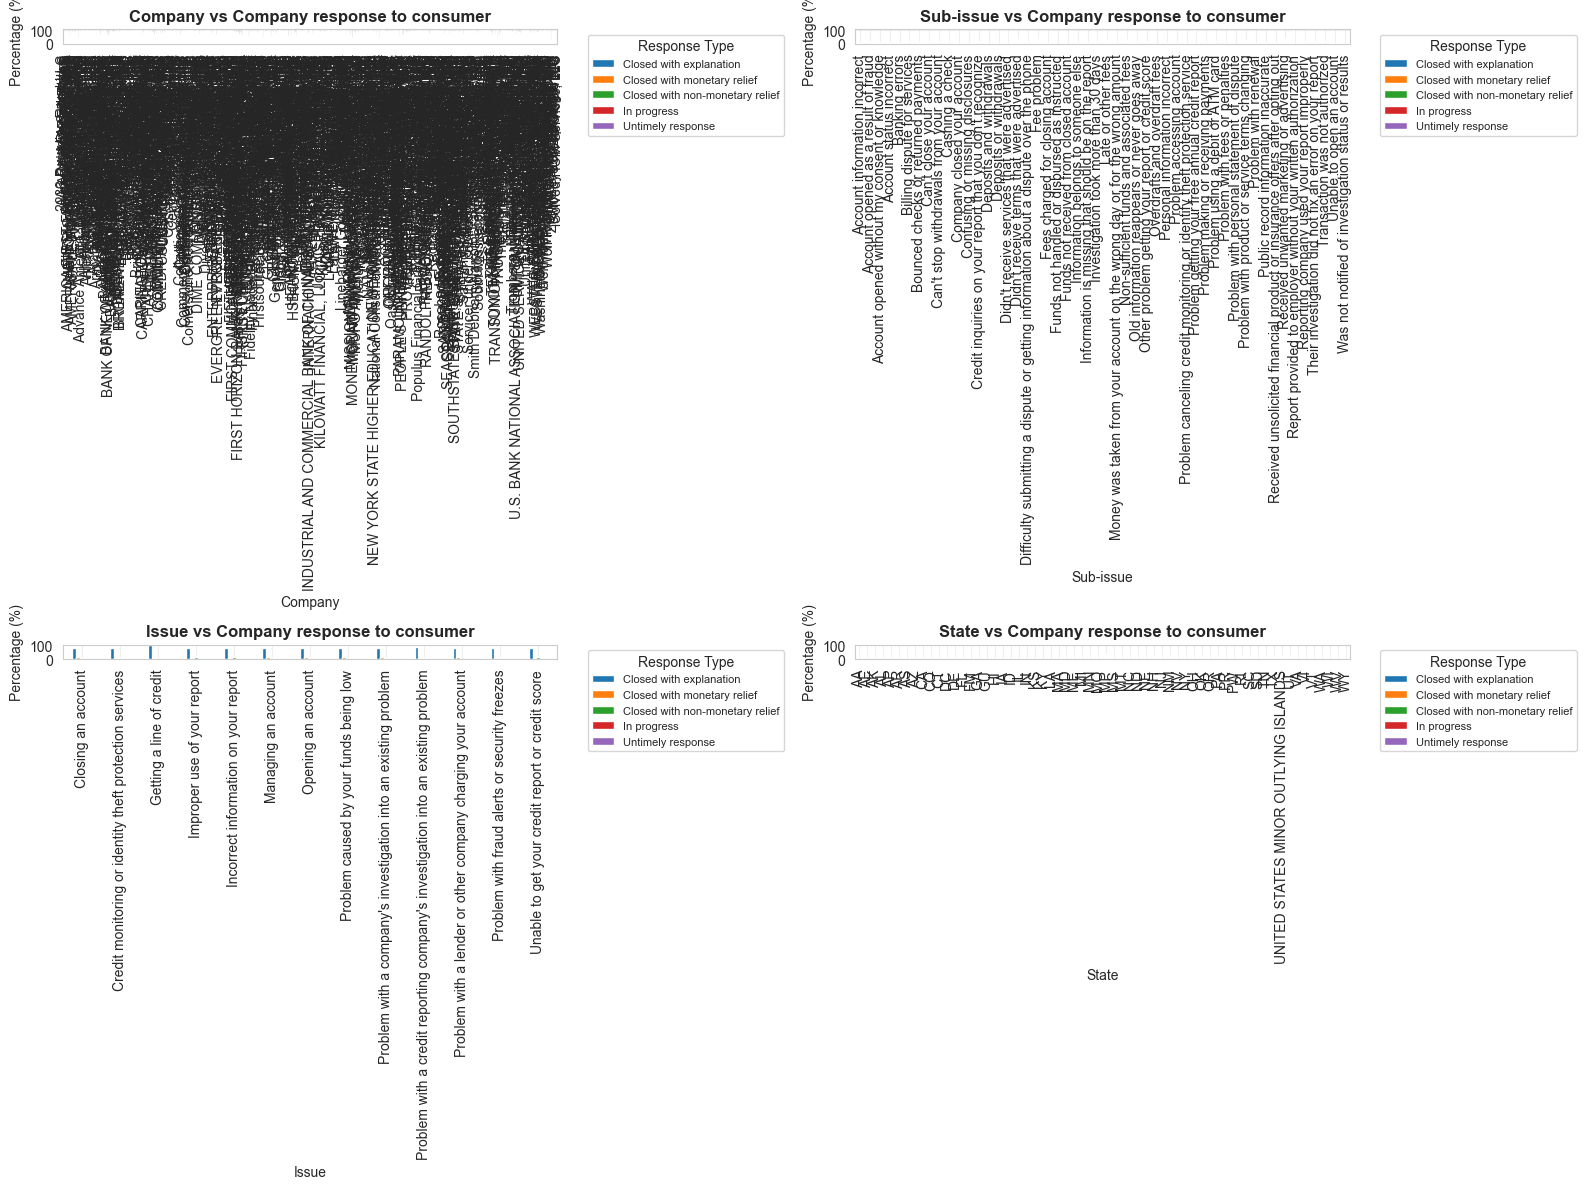

In [22]:
target = 'Company response to consumer'
print(f"\n{'='*80}")
print(f"Analysis: {target}")
print(f"{'='*80}\n")

# Analyze all relationships
results_company_response = analyze_target_field(df, input_fields, target)
results_company_response = results_company_response.sort_values('cramers_v', ascending=False)

# Display top associations
print(f"Top 10 associations with '{target}':")
print(results_company_response[['input_field', 'chi2', 'p_value', 'cramers_v']].head(10).to_string(index=False))

# Visualization: Top fields
top_fields = results_company_response.head(8)['input_field'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for idx, field in enumerate(top_fields[:4]):
    ax = axes[idx // 2, idx % 2]
    ct = pd.crosstab(df[field], df[target], margins=True)
    ct_pct = pd.crosstab(df[field], df[target], normalize='index') * 100
    ct_pct.plot(kind='bar', ax=ax, stacked=False)
    ax.set_title(f'{field} vs {target}', fontsize=12, fontweight='bold')
    ax.set_xlabel(field, fontsize=10)
    ax.set_ylabel('Percentage (%)', fontsize=10)
    ax.legend(title='Response Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('company_response_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
